---
title: "Midterm"
author: Karisa Kopecek
date: today
format:
  html:
    embed-resources: true
    echo: true
---


**By:** Karisa Kopecek 

**Target:** `accepted_offer` : binary (1 = accepted, 0 = did not accept)

**Methodology Overall**: This project followed a seven step workflow to predict whether a customer would accept an outreach offer. The data was first explored to understand class imbalance, which features separated acceptors from non-acceptors, and which columns had issues that needed fixing. Those findings directly guided data preparation, where skewed features were log-transformed, a value was replaced with a binary flag, and collinear economic columns were dropped. New features were then engineered from the cleaned data using ratios, interactions, and polynomial transformations, and SHAP values were used to identify and drop the 20 lowest signal columns, leaving 42 features for modeling. Three gradient boosting and bagging models were trained and tuned using RandomizedSearchCV followed by Optuna (manual info was done first and then fed into Optuna), with performance evaluated on a held out validation set using ROC-AUC as the primary metric (f1 score also used a bit). The three models were then combined using four ensemble strategies, with _____________________ as the final approach because _____________. Both models were retrained on the full training set before generating predictions on the test set.

**Seven Sections of my notebook**:

1. Exploratory Data Analysis
2. Data Preparation  
3. Feature Engineering and Feature Selection  
4. Modeling and Evaluation  
5. Ensembling  
6. Results Summary and Final Predictions
7. Final Model and Predictions


### 1. Exploratory Data Analysis

Goal: understand the data to make informed decisions. Used Sweetviz first and then looked at details with more custom plots.  Include a small number of relevant summaries or plots and focus on insights that influenced your modeling.

Focus on:
- Class imbalance 
- Which features show the strongest separation between classes
- Structural anomalies (skewed distributions etc)
- Multicollinearity, bad for models


In [350]:
#importing libraries and data 

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import sweetviz as sv
import warnings
warnings.filterwarnings('ignore')

# Consistent aesthetics across all plots
#adding info to make life easier later on in the notebook
C0 = '#2D6A4F'   # accepted (green)
C1 = '#D4A017'   # not accepted (gold)
BG = '#F7F7F5'
GRID = '#E0E0DC'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'axes.edgecolor': '#CCCCCC', 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.6,
    'font.family': 'sans-serif', 'font.size': 10,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'axes.labelsize': 9.5,
})

In [351]:
train = pd.read_csv('midterm_train.csv')
test  = pd.read_csv('midterm_test.csv')

#verifying everything loaded correctly, verifying the info in the data dictionary
print(f"Train: {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"Test:  {test.shape[0]:,} rows × {test.shape[1]} columns")
print()
print(train.dtypes)

Train: 32,950 rows × 23 columns
Test:  8,238 rows × 22 columns

id                             int64
customer_age                   int64
occupation_type               object
relationship_status           object
education_background          object
has_credit_issue              object
mortgage_status               object
personal_loan_status          object
last_contact_month            object
day_of_week                   object
contact_time_minutes           int64
contact_attempt_count          int64
days_since_prior_contact       int64
prior_contact_count            int64
prior_outcome_status          object
economic_activity_change     float64
consumer_price_index         float64
consumer_confidence_index    float64
reference_interest_rate      float64
employment_level_index       float64
accepted_offer                 int64
is_repeat_customer             int64
recent_contact_flag            int64
dtype: object


**Key takeaways from Sweetviz:**
- No missing values in any column 
- `days_since_prior_contact = 999` means "no prior contact" (affects 96% of records, needs handling)
- `has_credit_issue = "yes", mostly no or unknown
- economic features (`consumer_price_index`, `reference_interest_rate`, `employment_level_index`) appear collinear 

In [352]:
train = pd.read_csv('midterm_train.csv')
train.head()

# opening sweetviz report
report = sv.analyze(train, target_feat='accepted_offer')
report.show_html('sweetviz_report.html', open_browser=True)

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


**Dataset Summary**

In [353]:
# Missing values
missing = train.isnull().sum()
print(missing[missing > 0] if missing.any() else "None — clean dataset.")

# Numeric summary
print()
train.describe().T.round(2)

None — clean dataset.



,count,mean,std,min,25%,50%,75%,max
id,32950.0,20612.92,11872.66,0.00,10373.25,20610.50,30858.75,41187.00
customer_age,32950.0,40.02,10.42,17.00,32.00,38.00,47.00,98.00
contact_time_minutes,32950.0,257.36,256.69,0.00,102.00,180.00,318.00,4918.00
contact_attempt_count,32950.0,2.56,2.75,1.00,1.00,2.00,3.00,56.00
days_since_prior_contact,32950.0,961.75,188.70,0.00,999.00,999.00,999.00,999.00
prior_contact_count,32950.0,0.17,0.50,0.00,0.00,0.00,0.00,7.00
economic_activity_change,32950.0,0.08,1.57,-3.40,-1.80,1.10,1.40,1.40
consumer_price_index,32950.0,93.57,0.58,92.20,93.08,93.75,93.99,94.77
consumer_confidence_index,32950.0,-40.51,4.63,-50.80,-42.70,-41.80,-36.40,-26.90
reference_interest_rate,32950.0,3.61,1.74,0.63,1.34,4.86,4.96,5.04


In [354]:
# Categorical value counts
cats = train.select_dtypes('object').columns.tolist()
for c in cats:
    vc = train[c].value_counts()
    print(f"{c}: {dict(vc.head(5))}")

occupation_type: {'admin.': np.int64(8336), 'blue-collar': np.int64(7395), 'technician': np.int64(5384), 'services': np.int64(3182), 'management': np.int64(2350)}
relationship_status: {'married': np.int64(19889), 'single': np.int64(9319), 'divorced': np.int64(3674), 'unknown': np.int64(68)}
education_background: {'university.degree': np.int64(9772), 'high.school': np.int64(7609), 'basic.9y': np.int64(4806), 'professional.course': np.int64(4199), 'basic.4y': np.int64(3324)}
has_credit_issue: {'no': np.int64(26089), 'unknown': np.int64(6858), 'yes': np.int64(3)}
mortgage_status: {'yes': np.int64(17291), 'no': np.int64(14873), 'unknown': np.int64(786)}
personal_loan_status: {'no': np.int64(27168), 'yes': np.int64(4996), 'unknown': np.int64(786)}
last_contact_month: {'may': np.int64(10980), 'jul': np.int64(5743), 'aug': np.int64(4946), 'jun': np.int64(4262), 'nov': np.int64(3282)}
day_of_week: {'thu': np.int64(6893), 'mon': np.int64(6811), 'wed': np.int64(6497), 'tue': np.int64(6456), 'fri

**Class Imbalance Checking**

Summary:
The target is heavily imbalanced: only 11.3% of customers accepted the offer
- so accuracy is a misleading metric 
- I'll use **ROC-AUC** and **F1** as primary evaluation metrics: ROC-AUC is used because it evaluates how well the model separates acceptors from non-acceptors regardless of the decision threshold chosen. F1 is reported as a secondary metric because accuracy is misleading when only 11.3% of customers accepted
- need to deal with imbalance (maybe use class weighting or resampling)


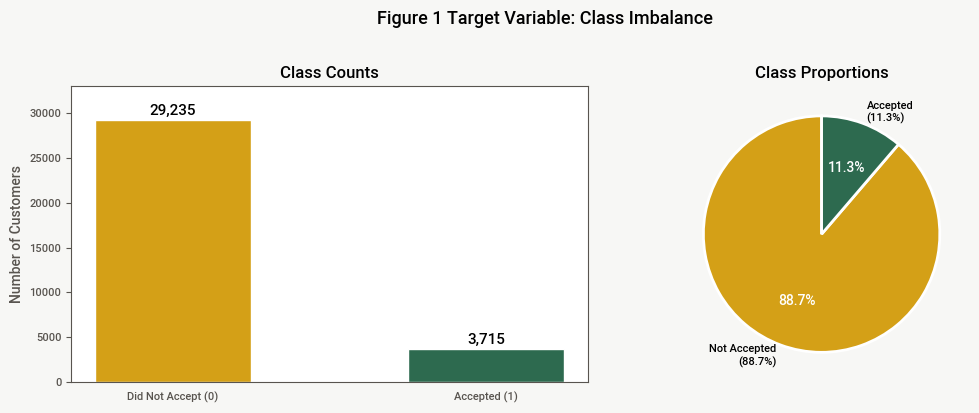

Acceptance rate: 11.27%
Imbalance ratio: 7.9:1


In [355]:
#creating a visual to see class imbalance

# Creating a figure with 2 side by side subplots (bar chart and pie chart)

# Set overall figure size and background color
fig, axes = plt.subplots(1, 2, figsize=(11, 4), facecolor=BG)

# Add a bold title slightly above the figure
fig.suptitle('Figure 1 Target Variable: Class Imbalance', fontsize=13, fontweight='bold', y=1.02)

# Get counts of each class (0 = not accepted, 1 = accepted), sorted by class label
counts = train['accepted_offer'].value_counts().sort_index()

# labels for the classes
labels = ['Did Not Accept (0)', 'Accepted (1)']

# Assign colors (assumes C1 = majority class, C0 = minority class)
colors = [C1, C0]

# BAR CHART (left subplot) 
# Plot class counts as a bar chart
bars = axes[0].bar(labels, counts.values, color=colors, width=0.5, edgecolor='white')

# Add value labels above each bar
for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,   # center of bar
        bar.get_height() + 200,            # slightly above bar
        f'{val:,}',                        # formatted with commas
        ha='center', va='bottom',
        fontweight='bold', fontsize=11
    )

# Set chart title and axis labels
axes[0].set_title('Class Counts')
axes[0].set_ylabel('Number of Customers')

# Fix y-axis limit for consistent scaling
axes[0].set_ylim(0, 33000)

# Remove bottom tick marks for cleaner look
axes[0].tick_params(bottom=False)


# PIE CHART (right subplot) 
# Plot class proportions as a pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values,
    labels=['Not Accepted\n(88.7%)', 'Accepted\n(11.3%)'],  # manually labeled percentages
    colors=[C1, C0],
    autopct='%1.1f%%',          # show percentages on slices
    startangle=90,              # rotate so first slice starts at top
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},  # clean slice borders
    pctdistance=0.6             # position percentage text closer to center
)

# percentage text inside pie slices
for at in autotexts:
    at.set_fontweight('bold')
    at.set_color('white')

# Set title for pie chart
axes[1].set_title('Class Proportions')


# Adjust layout to prevent overlap
fig.tight_layout()

# Display the figure
plt.show()


# SUMMARY METRICS
# Print overall acceptance rate (mean of binary target)
print(f"Acceptance rate: {train['accepted_offer'].mean()*100:.2f}%")

# Print imbalance ratio (majority : minority)
print(f"Imbalance ratio: {counts[0]/counts[1]:.1f}:1")

**Categorical Feature Analysis**

compute acceptance rates for some categorical features, want to see if certain categorical variables are very separated because I saw in my labs that that helped my modeling a lot especially when I engineered features off of those later

Only did this for KEY categorical features, or features I personally felt might be important to visualize first

- **`prior_outcome_status = 'success'`**: 63.7% acceptance rate vs. 8.9% for customers with no prior contact, seems to be a strongest predictor potentially
- **`occupation_type`**: Students (31.7%) and retired customers (25.8%) accept at much higher rates than blue-collar workers (6.9%). However, education type still matters as illiterate does lead to accepting more

-also, being single and separately also having no credit issues could also be leading to accepting



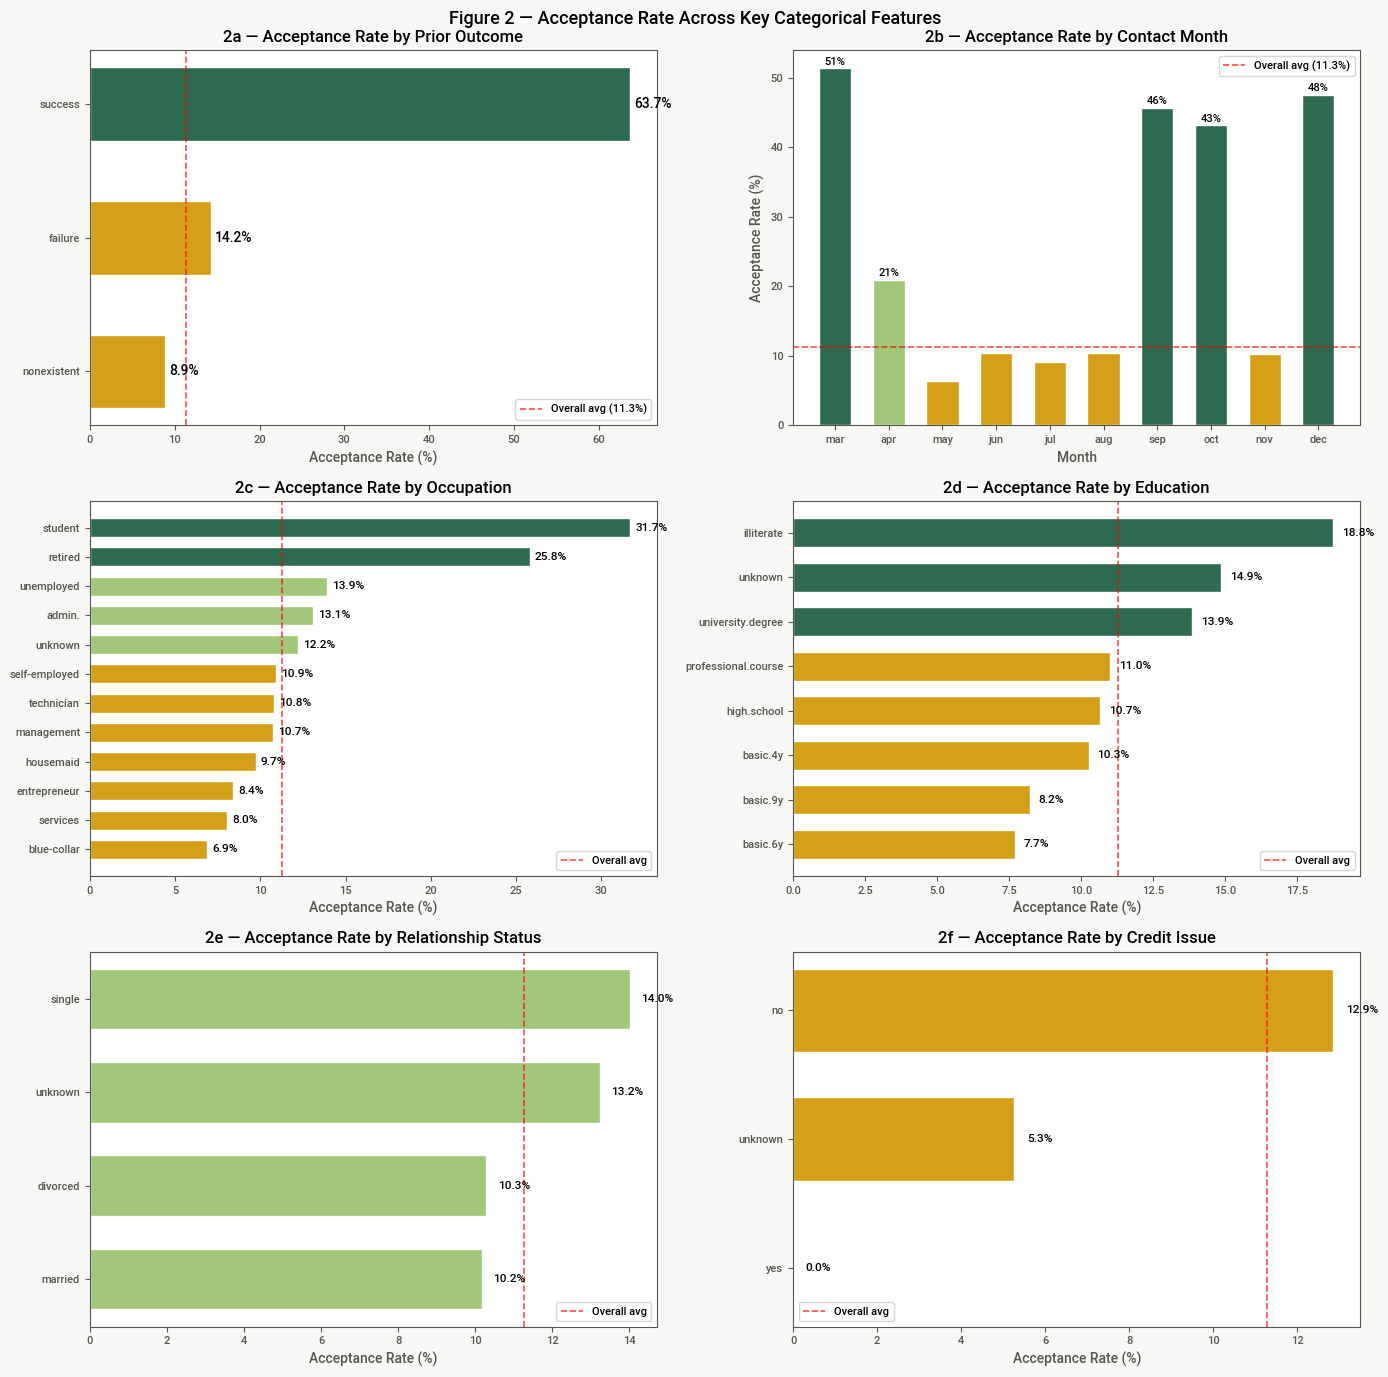

In [356]:
# making a bunch of graphs to look into things I think may be important

# Create a 3x2 grid of subplots for multiple feature analyses
# Set figure size and background color
fig, axes = plt.subplots(3, 2, figsize=(14, 14), facecolor=BG)

# Flatten axes array for easier indexing (so we can use axes[0], axes[1], etc.)
axes = axes.flatten()

# Compute overall acceptance rate (used as a reference line in plots)
overall_avg = train['accepted_offer'].mean() * 100


# 2a: Acceptance rate by prior outcome status 
# Group by prior outcome and compute mean acceptance rate (convert to %)
gr = train.groupby('prior_outcome_status')['accepted_offer'].mean().sort_values() * 100

# Assign colors dynamically based on acceptance rate thresholds
# High (>40%) = C0, Medium (>20%) = light green, Low = C1
colors_po = [C0 if v > 40 else '#A0C878' if v > 20 else C1 for v in gr.values]

# Plot horizontal bar chart
axes[0].barh(gr.index, gr.values, color=colors_po, edgecolor='white', height=0.55)

# Add percentage labels to each bar
for i, val in enumerate(gr.values):
    axes[0].text(
        val + 0.5,  # slightly to the right of bar
        i,          # vertical position
        f'{val:.1f}%',
        va='center',
        fontweight='bold'
    )

# Add vertical reference line for overall average acceptance rate
axes[0].axvline(
    overall_avg,
    color='red',
    ls='--',
    lw=1.2,
    alpha=0.7,
    label=f'Overall avg ({overall_avg:.1f}%)'
)

# Set subplot title and x-axis label
axes[0].set_title('2a — Acceptance Rate by Prior Outcome')
axes[0].set_xlabel('Acceptance Rate (%)')

# Show legend for the reference line
axes[0].legend(fontsize=8)


#for the rest following basically the same kind of process (see comments above), slightly changed depending on what I want to display
#sometimes made horizontal if that looked/fit better

# 2b: last_contact_month
# ended up not telling me too much
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
gr2 = train.groupby('last_contact_month')['accepted_offer'].mean().reindex(month_order).dropna() * 100
bar_colors = [C0 if v > 30 else '#A0C878' if v > 15 else C1 for v in gr2.values]
axes[1].bar(gr2.index, gr2.values, color=bar_colors, edgecolor='white', width=0.6)
axes[1].axhline(overall_avg, color='red', ls='--', lw=1.2, alpha=0.7, label=f'Overall avg ({overall_avg:.1f}%)')
axes[1].set_title('2b — Acceptance Rate by Contact Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Acceptance Rate (%)')
for i, (idx, val) in enumerate(gr2.items()):
    if val > 15:
        axes[1].text(i, val + 0.5, f'{val:.0f}%', ha='center', fontsize=8, fontweight='bold')
axes[1].legend(fontsize=8)

# 2c: occupation_type
gr3 = train.groupby('occupation_type')['accepted_offer'].mean().sort_values() * 100
occ_colors = [C0 if v > 25 else '#A0C878' if v > 12 else C1 for v in gr3.values]
axes[2].barh(gr3.index, gr3.values, color=occ_colors, edgecolor='white', height=0.65)
for i, val in enumerate(gr3.values):
    axes[2].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8.5)
axes[2].axvline(overall_avg, color='red', ls='--', lw=1.2, alpha=0.7, label='Overall avg')
axes[2].set_title('2c — Acceptance Rate by Occupation')
axes[2].set_xlabel('Acceptance Rate (%)')
axes[2].legend(fontsize=8)

# 2d: education_background
gr4 = train.groupby('education_background')['accepted_offer'].mean().sort_values() * 100
ed_colors = [C0 if v > 13 else C1 for v in gr4.values]
axes[3].barh(gr4.index, gr4.values, color=ed_colors, edgecolor='white', height=0.65)
for i, val in enumerate(gr4.values):
    axes[3].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8.5)
axes[3].axvline(overall_avg, color='red', ls='--', lw=1.2, alpha=0.7, label='Overall avg')
axes[3].set_title('2d — Acceptance Rate by Education')
axes[3].set_xlabel('Acceptance Rate (%)')
axes[3].legend(fontsize=8)

# 2e: relationship_status
gr5 = train.groupby('relationship_status')['accepted_offer'].mean().sort_values() * 100
rel_colors = [C0 if v > 20 else '#A0C878' if v > 10 else C1 for v in gr5.values]
axes[4].barh(gr5.index, gr5.values, color=rel_colors, edgecolor='white', height=0.65)
for i, val in enumerate(gr5.values):
    axes[4].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8.5)
axes[4].axvline(overall_avg, color='red', ls='--', lw=1.2, alpha=0.7, label='Overall avg')
axes[4].set_title('2e — Acceptance Rate by Relationship Status')
axes[4].set_xlabel('Acceptance Rate (%)')
axes[4].legend(fontsize=8)

# 2f: has_credit_issue
gr6 = train.groupby('has_credit_issue')['accepted_offer'].mean().sort_values() * 100
credit_colors = [C0 if v > 15 else C1 for v in gr6.values]
axes[5].barh(gr6.index.astype(str), gr6.values, color=credit_colors, edgecolor='white', height=0.65)
for i, val in enumerate(gr6.values):
    axes[5].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8.5)
axes[5].axvline(overall_avg, color='red', ls='--', lw=1.2, alpha=0.7, label='Overall avg')
axes[5].set_title('2f — Acceptance Rate by Credit Issue')
axes[5].set_xlabel('Acceptance Rate (%)')
axes[5].legend(fontsize=8)

fig.suptitle('Figure 2 — Acceptance Rate Across Key Categorical Features', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()


**Numeric Feature Analysis**

**Contact duration** (`contact_time_minutes`) shows the largest separation by outcome, customers who accepted had longer call time

**Age** accepted customers skew slightly older 

wasn't able to reaally see anything meaningful from the rest


**IMPORTANT ASSUMPTION: for my entire rest of the modeling etc, I am assuming that contact time is NOT data leakage, and instead the call happens, the duration is logged, and only after the call ends does the customer decide whether to accept the offer.**

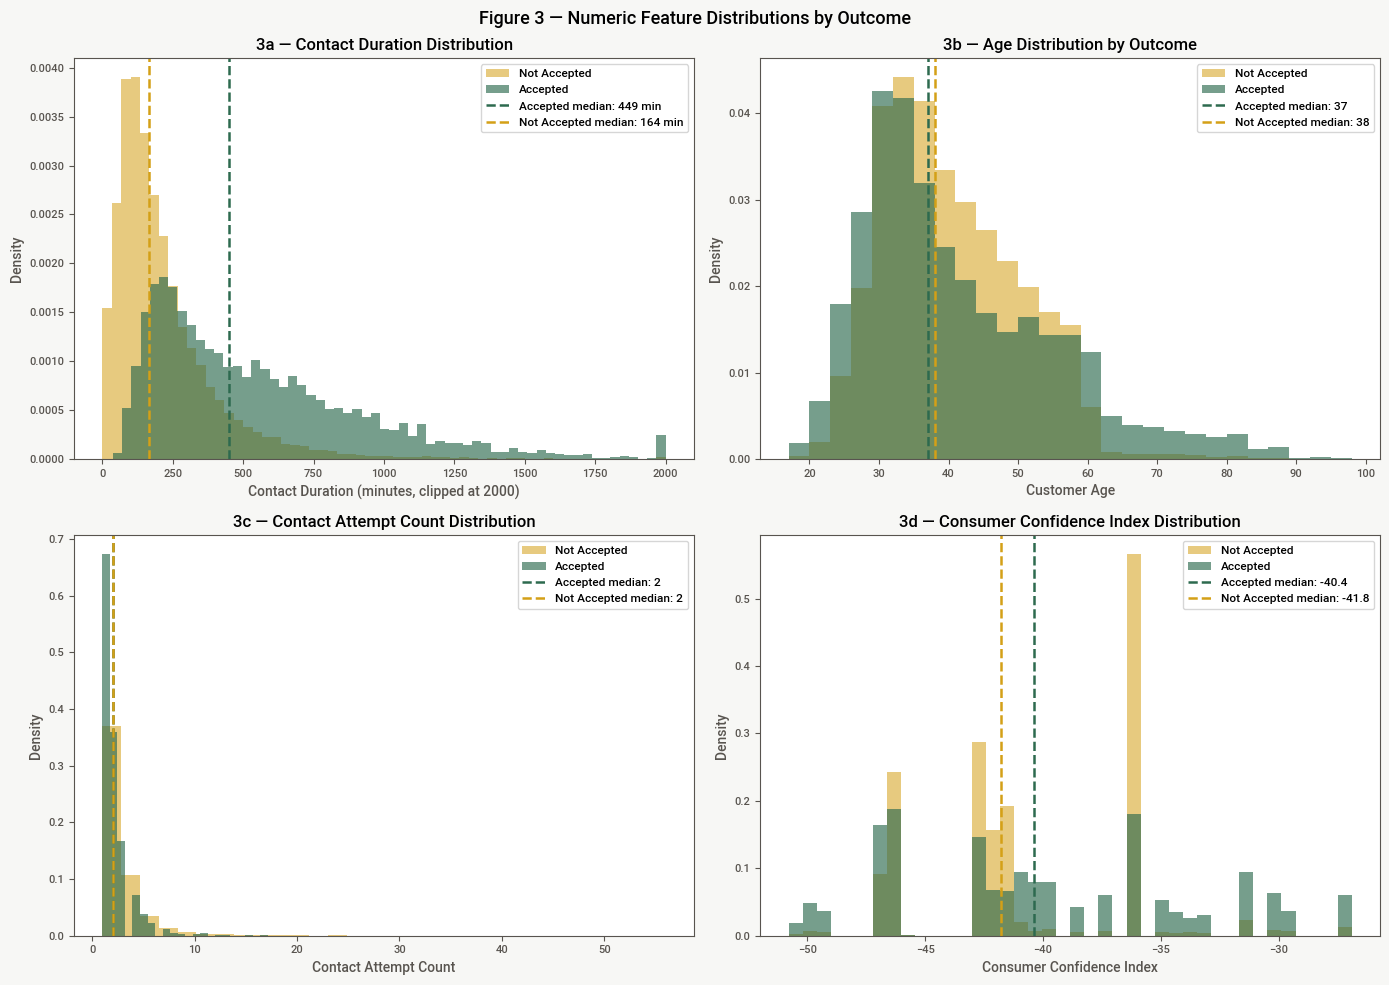

Accepted median contact time:  449 min
Rejected median contact time:  164 min
Ratio: 2.7x longer for acceptors
Accepted median age:  37
Rejected median age:  38
Accepted median contact attempts:  2
Rejected median contact attempts:  2
Accepted median consumer confidence index:  -40.4
Rejected median consumer confidence index:  -41.8


In [357]:
# Figure 3: numeric feature distributions by accepted vs not accepted outcome
# This compares how key numeric variables differ between customers who accepted
# the offer and customers who did not.

fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor=BG)
axes = axes.flatten()

# separating accepted and rejected groups once so we can reuse them
accepted = train[train['accepted_offer'] == 1]
rejected = train[train['accepted_offer'] == 0]

# 3a: contact_time_minutes
# clipping very large values so the histogram is easier to read
acc = accepted['contact_time_minutes'].clip(upper=2000)
rej = rejected['contact_time_minutes'].clip(upper=2000)

axes[0].hist(rej, bins=60, color=C1, alpha=0.55, density=True, label='Not Accepted', edgecolor='none')
axes[0].hist(acc, bins=60, color=C0, alpha=0.65, density=True, label='Accepted', edgecolor='none')
axes[0].axvline(acc.median(), color=C0, lw=1.8, ls='--', label=f'Accepted median: {int(acc.median())} min')
axes[0].axvline(rej.median(), color=C1, lw=1.8, ls='--', label=f'Not Accepted median: {int(rej.median())} min')
axes[0].set_title('3a — Contact Duration Distribution')
axes[0].set_xlabel('Contact Duration (minutes, clipped at 2000)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8.5)

# 3b: customer_age
# comparing age patterns between customers who accepted and did not accept
acc_age = accepted['customer_age']
rej_age = rejected['customer_age']

bins = range(17, 99, 3)
axes[1].hist(rej_age, bins=bins, color=C1, alpha=0.55, density=True, label='Not Accepted', edgecolor='none')
axes[1].hist(acc_age, bins=bins, color=C0, alpha=0.65, density=True, label='Accepted', edgecolor='none')
axes[1].axvline(acc_age.median(), color=C0, lw=1.8, ls='--', label=f'Accepted median: {int(acc_age.median())}')
axes[1].axvline(rej_age.median(), color=C1, lw=1.8, ls='--', label=f'Not Accepted median: {int(rej_age.median())}')
axes[1].set_title('3b — Age Distribution by Outcome')
axes[1].set_xlabel('Customer Age')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8.5)

# 3c: contact_attempt_count
# checking whether accepted customers needed fewer or more contact attempts
acc_attempts = accepted['contact_attempt_count']
rej_attempts = rejected['contact_attempt_count']

axes[2].hist(rej_attempts, bins=30, color=C1, alpha=0.55, density=True, label='Not Accepted', edgecolor='none')
axes[2].hist(acc_attempts, bins=30, color=C0, alpha=0.65, density=True, label='Accepted', edgecolor='none')
axes[2].axvline(acc_attempts.median(), color=C0, lw=1.8, ls='--', label=f'Accepted median: {acc_attempts.median():.0f}')
axes[2].axvline(rej_attempts.median(), color=C1, lw=1.8, ls='--', label=f'Not Accepted median: {rej_attempts.median():.0f}')
axes[2].set_title('3c — Contact Attempt Count Distribution')
axes[2].set_xlabel('Contact Attempt Count')
axes[2].set_ylabel('Density')
axes[2].legend(fontsize=8.5)

# 3d: consumer_confidence_index
# comparing whether acceptance differs under different confidence levels
acc_conf = accepted['consumer_confidence_index']
rej_conf = rejected['consumer_confidence_index']

axes[3].hist(rej_conf, bins=40, color=C1, alpha=0.55, density=True, label='Not Accepted', edgecolor='none')
axes[3].hist(acc_conf, bins=40, color=C0, alpha=0.65, density=True, label='Accepted', edgecolor='none')
axes[3].axvline(acc_conf.median(), color=C0, lw=1.8, ls='--', label=f'Accepted median: {acc_conf.median():.1f}')
axes[3].axvline(rej_conf.median(), color=C1, lw=1.8, ls='--', label=f'Not Accepted median: {rej_conf.median():.1f}')
axes[3].set_title('3d — Consumer Confidence Index Distribution')
axes[3].set_xlabel('Consumer Confidence Index')
axes[3].set_ylabel('Density')
axes[3].legend(fontsize=8.5)

fig.suptitle('Figure 3 — Numeric Feature Distributions by Outcome', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

# summary statistics for quick interpretation
print(f"Accepted median contact time:  {acc.median():.0f} min")
print(f"Rejected median contact time:  {rej.median():.0f} min")
print(f"Ratio: {acc.median()/rej.median():.1f}x longer for acceptors")

print(f"Accepted median age:  {acc_age.median():.0f}")
print(f"Rejected median age:  {rej_age.median():.0f}")

print(f"Accepted median contact attempts:  {acc_attempts.median():.0f}")
print(f"Rejected median contact attempts:  {rej_attempts.median():.0f}")

print(f"Accepted median consumer confidence index:  {acc_conf.median():.1f}")
print(f"Rejected median consumer confidence index:  {rej_conf.median():.1f}")

**looking into Campaign Contact Behavior**

Was hard to see `contact_attempt_count` previously, so made new graph which shows higher attempt counts correlate with lower acceptance

`days_since_prior_contact = 999` means "never been contacted before." This affects 96.25% of the training data. need to make 0 or 1 flag instead I think

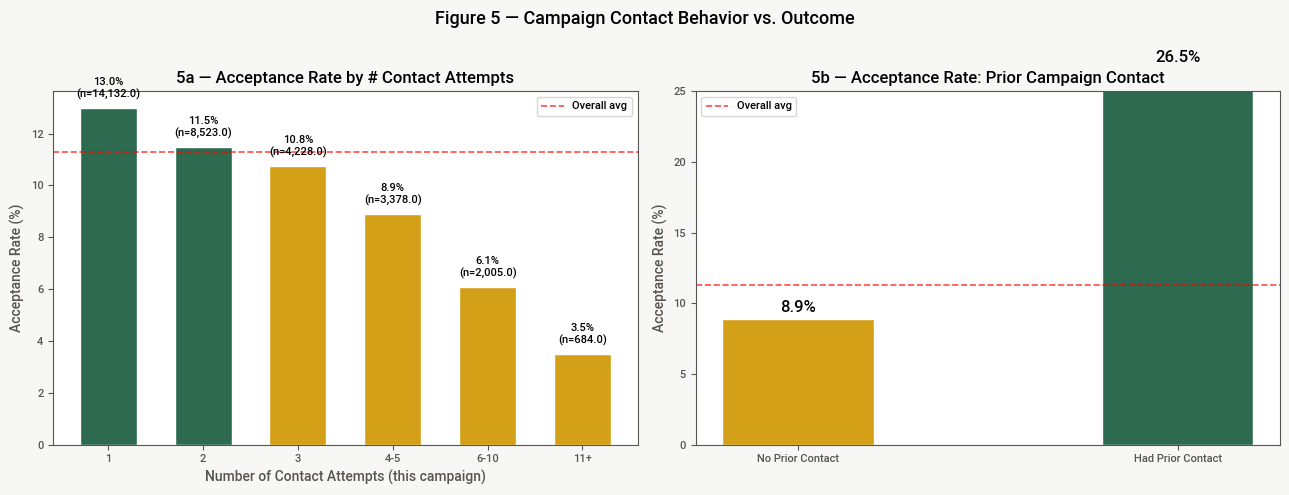

days_since_prior_contact = 999: 31,714 rows (96.2%)


In [358]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

# Acceptance rate by number of contact attempts (binned)
train['attempt_bin'] = pd.cut(train['contact_attempt_count'],
                               bins=[0,1,2,3,5,10,56],
                               labels=['1','2','3','4-5','6-10','11+'])
gr5 = train.groupby('attempt_bin', observed=True)['accepted_offer'].agg(['mean','count'])
gr5['mean'] *= 100
colors5 = [C0 if v > 11 else C1 for v in gr5['mean'].values]
bars5 = axes[0].bar(gr5.index.astype(str), gr5['mean'], color=colors5, edgecolor='white', width=0.6)
for bar, (idx, row) in zip(bars5, gr5.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{row["mean"]:.1f}%\n(n={row["count"]:,})',
                 ha='center', va='bottom', fontsize=8)
axes[0].axhline(train['accepted_offer'].mean()*100, color='red', ls='--', lw=1.2, alpha=0.7, label='Overall avg')
axes[0].set_title('5a — Acceptance Rate by # Contact Attempts')
axes[0].set_xlabel('Number of Contact Attempts (this campaign)')
axes[0].set_ylabel('Acceptance Rate (%)')
axes[0].legend(fontsize=8)

# Prior campaign contact vs. no prior contact
train['had_prior'] = (train['prior_contact_count'] > 0).astype(int)
gr6 = train.groupby('had_prior')['accepted_offer'].mean() * 100
axes[1].bar(['No Prior Contact', 'Had Prior Contact'], gr6.values,
            color=[C1, C0], edgecolor='white', width=0.4)
for bar, val in zip(axes[1].patches, gr6.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].axhline(train['accepted_offer'].mean()*100, color='red', ls='--', lw=1.2, alpha=0.7, label='Overall avg')
axes[1].set_title('5b — Acceptance Rate: Prior Campaign Contact')
axes[1].set_ylabel('Acceptance Rate (%)')
axes[1].set_ylim(0, 25)
axes[1].legend(fontsize=8)

fig.suptitle('Figure 5 — Campaign Contact Behavior vs. Outcome', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

# Clean up temp columns
train.drop(columns=['attempt_bin','had_prior'], inplace=True)

print(f"days_since_prior_contact = 999: {(train['days_since_prior_contact']==999).sum():,} rows ({(train['days_since_prior_contact']==999).mean()*100:.1f}%)")

**Deeper dive into Economic Features**

Disclaimer: These features might capture *when* in the business cycle the campaign ran rather than meaningful patterns, but chose to look into them to see

overall Low confidence periods may push customers toward safer financial products (I think based on the graphs, still hard to read)


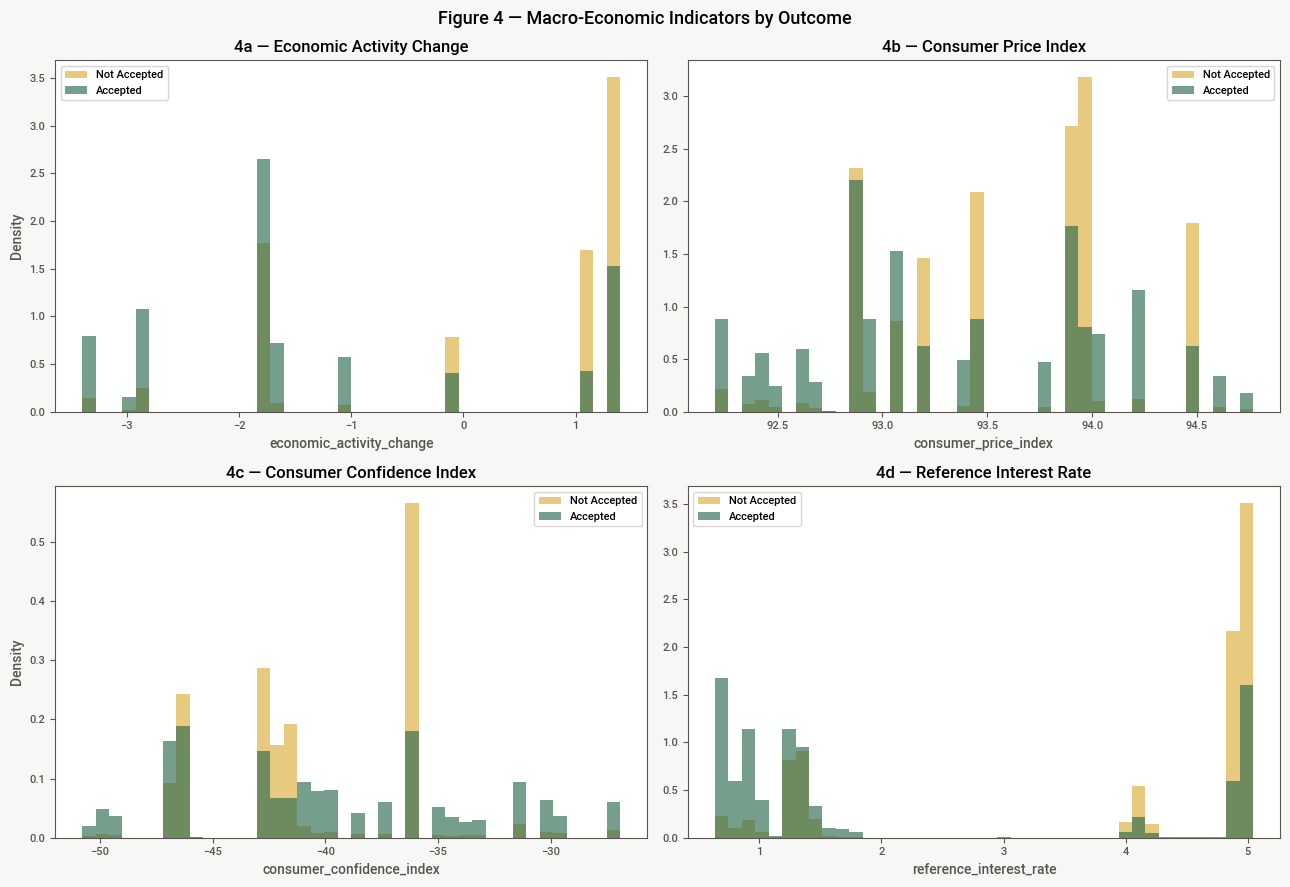

In [359]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), facecolor=BG)
axes = axes.flatten()

macro = ['economic_activity_change','consumer_price_index',
         'consumer_confidence_index','reference_interest_rate']
titles = ['Economic Activity Change','Consumer Price Index',
          'Consumer Confidence Index','Reference Interest Rate']

for i, (col, title) in enumerate(zip(macro, titles)):
    acc_v = train[train['accepted_offer']==1][col]
    rej_v = train[train['accepted_offer']==0][col]
    axes[i].hist(rej_v, bins=40, color=C1, alpha=0.55, density=True, label='Not Accepted', edgecolor='none')
    axes[i].hist(acc_v, bins=40, color=C0, alpha=0.65, density=True, label='Accepted', edgecolor='none')
    axes[i].set_title(f'4{chr(97+i)} — {title}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density' if i % 2 == 0 else '')
    axes[i].legend(fontsize=8)

fig.suptitle('Figure 4 — Macro-Economic Indicators by Outcome', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

**Multicollinearity**

I know sweetviz also shows this, but was hard to read because of small text in some areas, so redid

MANY economic features are strongly correlated (r > 0.9)


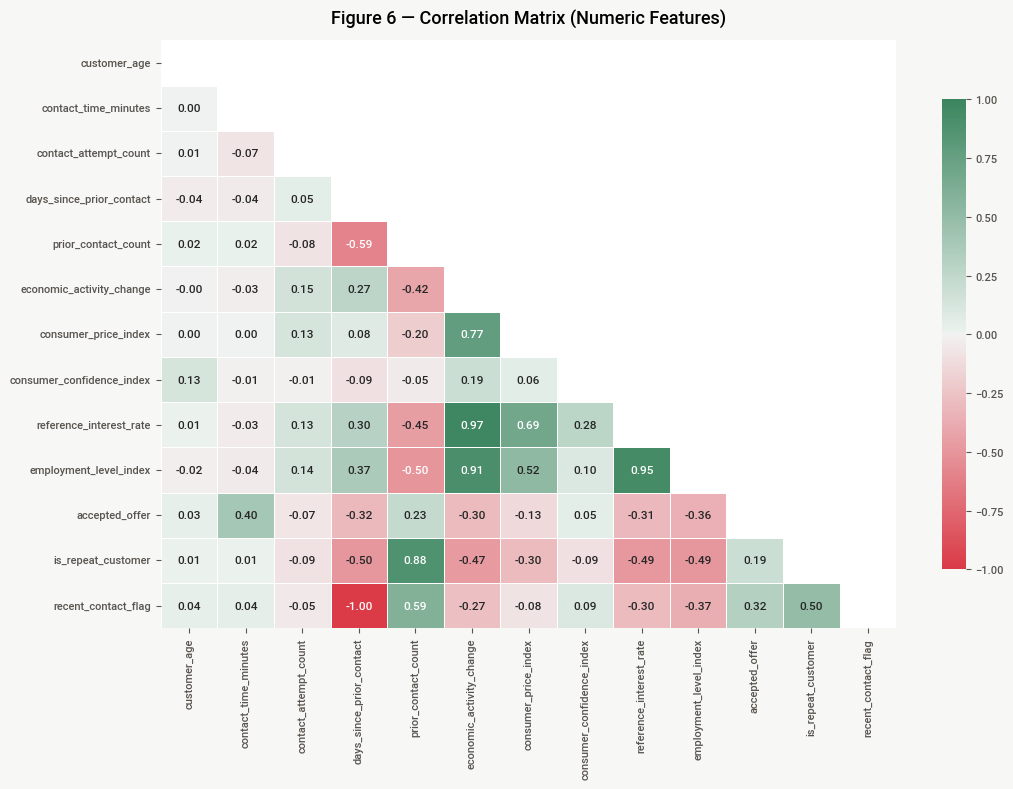

Highly correlated pairs (|r| > 0.75):
  days_since_prior_contact            × recent_contact_flag                  r = -1.0
  economic_activity_change            × reference_interest_rate              r = 0.972
  reference_interest_rate             × employment_level_index               r = 0.945
  economic_activity_change            × employment_level_index               r = 0.906
  prior_contact_count                 × is_repeat_customer                   r = 0.879
  economic_activity_change            × consumer_price_index                 r = 0.775


In [360]:
fig, ax = plt.subplots(figsize=(11, 8), facecolor=BG)
numeric_cols = train.select_dtypes('number').drop(columns=['id'])
corr = numeric_cols.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(10, 145, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 8.5},
            linewidths=0.5, linecolor='white',
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Figure 6 — Correlation Matrix (Numeric Features)', fontsize=13, fontweight='bold', pad=12)
fig.tight_layout()
plt.show()

# Flag high correlations
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.75:
            high_corr.append((corr.columns[i], corr.columns[j], round(r, 3)))
print("Highly correlated pairs (|r| > 0.75):")
for a, b, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {a:35s} × {b:35s}  r = {r}")

**EDA summary**

| Finding                                                        | Modeling Implication                                                                     |
| -------------------------------------------------------------- | ---------------------------------------------------------------------------------------- |
| **~11.3% acceptance rate** : pretty imbalanced                 | Accuracy alone won’t be useful, focus more on ROC-AUC / F1 and likely use class weights  |
| **`prior_outcome_status = 'success'`** is way higher (~63–64%) | Clearly one of the strongest signals; consider interactions with other features |
| **`contact_time_minutes`** : much longer for acceptors (~2.7x) | Strong predictor (log transform?)                               |
| **`days_since_prior_contact = 999`** in most rows              | better to convert into a “previously contacted” flag                   |
| **Students / retired** accept a lot more than other groups     | Occupation seems important                       |
| **economic features** look highly correlated                      | drop some or reduce          |
| **`has_credit_issue = "yes"`** shows up almost never           | Too sparse to be useful alone                                     |
| **Contact attempts** don’t always help after a point           | Looks like diminishing returns (log transform?)         |
| **No missing values**                                          | not too much cleaning needed, but still need to handle values like 999               |



### 2. Data Preparation: Show the preprocessing steps used for modeling.

Goal: drop and fix any data issues that might bleed into the models, show the preprocessing steps used for modeling.

**Days_since_prior_contact issue fix** `999` means "no prior contact ever" and affects 96.25% of rows, replacing with binary 0 or 1 <- this is from the eda

In [361]:
for df in [train, test]:
    # create flag: 1 = previously contacted, 0 = never contacted
    df['was_previously_contacted'] = (df['days_since_prior_contact'] != 999).astype(int)
    
    # drop original column since it doesn’t add useful signal anymore
    df.drop(columns=['days_since_prior_contact'], inplace=True)

# quick check to see how many were actually contacted before
print("Pct previously contacted (train):", round(train['was_previously_contacted'].mean() * 100, 2), "%")

Pct previously contacted (train): 3.75 %


**has_credit_issues : yes appears only 3 times** - from sweetviz

going to put yes into unknown to prevent model from overfitting a ton to these 3 yesses


In [362]:
for df in [train, test]:
    # replace rare 'yes' values with 'unknown'
    df['has_credit_issue'] = df['has_credit_issue'].replace('yes', 'unknown')

# quick check to confirm distribution after change
print(train['has_credit_issue'].value_counts())

has_credit_issue
no         26089
unknown     6861
Name: count, dtype: int64


**log transform features that are more skewed**

`contact_time_minutes` has a skew of 3.19 and `contact_attempt_count` has a skew of 4.82

Log transforming might bring them closer to symmetric, which helps linear models and reduces influence of extreme values for any tree-based models I might make

In [363]:
# log1p handles zeros safely (log1p(0) = 0)
for df in [train, test]:
    df['contact_time_minutes']  = np.log1p(df['contact_time_minutes'])
    df['contact_attempt_count'] = np.log1p(df['contact_attempt_count'])

# verifying skew reduction
print("contact_time_minutes skew after log:", round(train['contact_time_minutes'].skew(), 2))
print("contact_attempt_count skew after log:", round(train['contact_attempt_count'].skew(), 2))

contact_time_minutes skew after log: -0.43
contact_attempt_count skew after log: 1.35


**dropping colinear economic features**

The correlation matrix from EDA showed `consumer_price_index`, `consumer_confidence_index`, and `employment_level_index` are highly correlated with each other and with `reference_interest_rate` and `economic_activity_change`. Keeping all five adds noise. I keep the ones with the strongest individual correlation to the target (`employment_level_index` , `reference_interest_rate` etc) and drop the rest.

In [364]:
# checking correlation of macro features with target before deciding what to drop
macro_cols = [
    'economic_activity_change',
    'reference_interest_rate',
    'employment_level_index',
    'consumer_price_index',
    'consumer_confidence_index'
]

# compute correlations with target
corrs = train[macro_cols + ['accepted_offer']].corr()['accepted_offer'].drop('accepted_offer').sort_values()

print("Correlation with accepted_offer:")
print(corrs)

# based on correlation and EDA, keeping stronger ones and dropping weaker/redundant ones
drop_macro = ['consumer_price_index', 'consumer_confidence_index']

train.drop(columns=drop_macro, inplace=True)
test.drop(columns=drop_macro, inplace=True)

print("\nRemaining macro features:",
      [c for c in train.columns if any(m in c for m in ['economic','interest','employment','confidence','price'])])

Correlation with accepted_offer:
employment_level_index      -0.355823
reference_interest_rate     -0.308602
economic_activity_change    -0.298351
consumer_price_index        -0.134264
consumer_confidence_index    0.050504
Name: accepted_offer, dtype: float64

Remaining macro features: ['economic_activity_change', 'reference_interest_rate', 'employment_level_index']


**categorical columns one hot encoding**

All remaining categorical columns are one-hot encoded to convert them into numeric form that the models can use. I set `drop='first'` to avoid redundancy. One shared feature matrix meant one pipeline for all three models, which kept the code clean and made the comparison between models fair since they all saw identical input (I know technically catboost and all models could be fed separate piplines and handle categorical columns natively, but I wanted to be sure all the models were seeing things the same way and one hot encoding didn't seem to hurt anything).

After encoding, the dataset ends up with 51 columns, which is still a manageable size, so there’s no concern about having too many features. The same encoding structure is applied to both train and test data to keep them consistent and avoid issues during prediction.


In [365]:
cat_cols = train.select_dtypes('object').columns.tolist()
print("Columns to encode:", cat_cols)

# one-hot encode — keeping accepted_offer out of encoding, it stays in train
train_features = train.drop(columns=['accepted_offer', 'id'])  # drop id here
train_enc = pd.get_dummies(train_features, columns=cat_cols, drop_first=True)
test_enc  = pd.get_dummies(test,  columns=cat_cols, drop_first=True)

# align test to train columns in case any categories are missing
test_enc = test_enc.reindex(columns=train_enc.columns, fill_value=0)

print(f"\nShape after encoding — Train: {train_enc.shape}, Test: {test_enc.shape}")

Columns to encode: ['occupation_type', 'relationship_status', 'education_background', 'has_credit_issue', 'mortgage_status', 'personal_loan_status', 'last_contact_month', 'day_of_week', 'prior_outcome_status']

Shape after encoding — Train: (32950, 51), Test: (8238, 51)


**Train / Validation Split** 

Using a stratified 80/20 split so the 11.3% positive class rate is preserved in both sets. The validation set is held out from all tuning decisions.

In [366]:
from sklearn.model_selection import train_test_split

# extracting target here so this cell is self-contained
y = train['accepted_offer']
train_enc_model = train_enc.copy()

X_train, X_val, y_train, y_val = train_test_split(
    train_enc_model, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # preserves class ratio in both splits
)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"Positive rate — train: {y_train.mean():.3f}, val: {y_val.mean():.3f}")

X_train: (26360, 51), X_val: (6590, 51)
Positive rate — train: 0.113, val: 0.113


In [367]:
#double checking everything I think should be there (aka no nulls etc)
print("Nulls in X_train:", X_train.isnull().sum().sum())
print("Nulls in test_enc:", test_enc.isnull().sum().sum())
print("Features in train vs test:", X_train.shape[1], "==", test_enc.shape[1])
print()
print("Final feature list:")
print(list(X_train.columns))

Nulls in X_train: 0
Nulls in test_enc: 0
Features in train vs test: 51 == 51

Final feature list:
['customer_age', 'contact_time_minutes', 'contact_attempt_count', 'prior_contact_count', 'economic_activity_change', 'reference_interest_rate', 'employment_level_index', 'is_repeat_customer', 'recent_contact_flag', 'was_previously_contacted', 'occupation_type_blue-collar', 'occupation_type_entrepreneur', 'occupation_type_housemaid', 'occupation_type_management', 'occupation_type_retired', 'occupation_type_self-employed', 'occupation_type_services', 'occupation_type_student', 'occupation_type_technician', 'occupation_type_unemployed', 'occupation_type_unknown', 'relationship_status_married', 'relationship_status_single', 'relationship_status_unknown', 'education_background_basic.6y', 'education_background_basic.9y', 'education_background_high.school', 'education_background_illiterate', 'education_background_professional.course', 'education_background_university.degree', 'education_backgroun

**Data Preparation Summary**

| Step | What | Why |
|---|---|---|
| Drop `id` | Removed before modeling | Identifier, not a predictor |
| `days_since_prior_contact` | Converted 999 sentinel to binary flag `was_previously_contacted` | raw value uninformative |
| `has_credit_issue` | Collapsed "yes" (3 rows) into "unknown" | Too sparse to learn from |
| Log-transform | Applied `log1p` to `contact_time_minutes` and `contact_attempt_count` | Both had skew > 3; log reduces tail influence |
| Drop some economic features | Dropped `consumer_price_index` and `consumer_confidence_index` | Highly collinear with other economic features |
| One-hot encode | All nominal categoricals, `drop_first=True` | Might just make my life easier for feeding things into models |
| Stratified split | 80/20 train/val, `stratify=y` | Preserves 11.3% positive rate in both sets |

### 3. Feature Engineering or Feature Selection

Goal: Evaluate whether feature engineering or feature selection improved or simplified your model. use SHAP to evaluate which features matter.

**Initial logic**

| Engineered Feature | Approach | Source | Logic |
|---|---|---|---|
| `contact_efficiency` | Ratio | Hypothesis | Call time divided by number of attempts, a long first call signals genuine interest differently than the same total time spread across many attempts |
| `age_x_long_call` | Interaction | Hypothesis | Age multiplied by call duration, older customers who engage for a long time are likely more serious |
| `single_x_no_debt` | Interaction | EDA + Hypothesis | Single status (14% acceptance) combined with no mortgage and no personal loan, financially flexible customers who are also unattached |
| `age_squared` | Polynomial | EDA | Age showed a non-linear relationship with acceptance in EDA; squaring captures the curve where very young and very old accept at higher rates than middle age |
| `campaign_pressure` | Ratio | EDA | Contact attempts divided by prior contact count, high pressure with no prior relationship may signal desperation |
| `contact_time_x_peak` | Interaction | EDA | Log call duration multiplied by peak season, a long call in a historically high acceptance month makes stronger signal overall |
| `high_value_occ_x_single` | Interaction | EDA | Student or retired flag multiplied by single flag, the two highest-acceptance occupation groups, filtered further by relationship status |
| `prior_contact_rate` | Ratio | Hypothesis | Prior contact count divided by customer age, normalizes engagement history by how long the customer has potentially been in the system |
| `macro_environment` | Combination | EDA | Employment level index minus reference interest rate, summarizes whether the environment at contact time was favorable |
| `low_season_x_overload` | Interaction | EDA | Low-acceptance month (May/July) combined with high attempt count, worst-case contact scenario |
| `age_group_encoded` | Binning + Encoding | EDA | Age split into meaningful groups (youth/early-career/mid-career/pre-retirement/retirement) and encoded by their observed acceptance rate |

In [368]:
def engineer_features(df, fit_df=None):
    # fit_df is used to compute statistics (like medians) on training data only
    # and apply them to test, prevents leakage from test set into transformations
    d = df.copy()
    ref = fit_df if fit_df is not None else df

    # Ratio features 

    # contact efficiency: call time divided by number of attempts
    # captures whether engagement was concentrated (one long call) or diluted (many short ones)
    d['contact_efficiency'] = d['contact_time_minutes'] / (d['contact_attempt_count'] + 0.01)

    # campaign pressure: how many times called this campaign vs prior campaign history
    # high values mean the campaign is pushing hard on someone with little prior relationship
    d['campaign_pressure'] = d['contact_attempt_count'] / (d['prior_contact_count'] + 0.01)

    # prior contact rate: prior contacts normalized by age
    # older customers with few prior contacts may have been harder to engage historically
    d['prior_contact_rate'] = d['prior_contact_count'] / (d['customer_age'] + 1)

    # Polynomial features 

    # age squared: EDA showed non-linear acceptance pattern across age groups
    # squaring lets the model fit a curve rather than assuming a linear age effect
    age_mean = ref['customer_age'].mean()
    age_std  = ref['customer_age'].std()
    d['age_squared'] = ((d['customer_age'] - age_mean) / age_std) ** 2

    # Interaction features

    # age x log call duration: older customers who stay on the phone longer
    # multiplying creates a joint signal that neither column captures individually
    d['age_x_long_call'] = d['customer_age'] * d['contact_time_minutes']

    # long call in a high-acceptance month: compounds two positive signals
    # a long call in March/December/September/October is a stronger signal than either alone
    peak = d['last_contact_month'].isin(['mar', 'dec', 'sep', 'oct']).astype(int)
    d['contact_time_x_peak'] = d['contact_time_minutes'] * peak

    # single and no debt: relationship flexibility combined with financial flexibility
    # single had 14% acceptance in EDA; combining with no-debt adds a second filter
    no_debt = ((d['mortgage_status'] == 'no') & (d['personal_loan_status'] == 'no')).astype(int)
    d['single_x_no_debt'] = (d['relationship_status'] == 'single').astype(int) * no_debt

    # high-value occupation AND single: student/retired (highest-accepting groups) who are also single
    high_occ = d['occupation_type'].isin(['student', 'retired']).astype(int)
    d['high_value_occ_x_single'] = high_occ * (d['relationship_status'] == 'single').astype(int)

    # low-acceptance month AND high attempt count: double negative signal
    # being called many times in May or July is the worst-case contact scenario
    low_season   = d['last_contact_month'].isin(['may', 'jul']).astype(int)
    overload     = (d['contact_attempt_count'] > np.log1p(3)).astype(int)
    d['low_season_x_overload'] = low_season * overload

    # Combination / constructed features 

    # macro environment score: standardized employment index minus standardized interest rate
    # positive = high employment + low rates = favorable economic conditions
    emp_mean  = ref['employment_level_index'].mean()
    emp_std   = ref['employment_level_index'].std()
    rate_mean = ref['reference_interest_rate'].mean()
    rate_std  = ref['reference_interest_rate'].std()
    d['macro_environment'] = (
        (d['employment_level_index']   - emp_mean)  / emp_std -
        (d['reference_interest_rate']  - rate_mean) / rate_std
    )

    # Binning + ordinal encoding 

    # age groups encoded by observed acceptance rate from EDA
    # bins are meaningful life stages, not arbitrary cutoffs
    # ordered from lowest to highest average acceptance rate so encoding carries signal
    bins   = [0,  25,  35,  50,  60, 100]
    labels = ['youth', 'early_career', 'mid_career', 'pre_retirement', 'retirement']
    d['age_group'] = pd.cut(d['customer_age'], bins=bins, labels=labels, right=False)

    # ordinal encoding: assign rank by acceptance rate observed in EDA
    # youth and retirement had highest rates; mid-career lowest
    age_order = {'mid_career': 0, 'early_career': 1, 'pre_retirement': 2,
                 'youth': 3, 'retirement': 4}
    d['age_group_encoded'] = d['age_group'].map(age_order).astype(float)
    d.drop(columns=['age_group'], inplace=True)

    return d

# fit_df=train ensures all statistics (means, medians) come from training data only
train = engineer_features(train, fit_df=train)
test  = engineer_features(test,  fit_df=train)

engineered = [
    'contact_efficiency', 'campaign_pressure', 'prior_contact_rate',
    'age_squared', 'age_x_long_call', 'contact_time_x_peak',
    'single_x_no_debt', 'high_value_occ_x_single', 'low_season_x_overload',
    'macro_environment', 'age_group_encoded'
]

print("Engineered features added:", engineered)

Engineered features added: ['contact_efficiency', 'campaign_pressure', 'prior_contact_rate', 'age_squared', 'age_x_long_call', 'contact_time_x_peak', 'single_x_no_debt', 'high_value_occ_x_single', 'low_season_x_overload', 'macro_environment', 'age_group_encoded']


- **Binary features**: bar chart showing acceptance rate when the flag is 0 vs 1
- **Ordinal feature**: bar chart showing acceptance rate at each encoded level
- **Continuous features**: overlapping histograms, if the green and gold distributions are in different places, the feature has signal

In [369]:
# validate that each feature works
# checking that each feature actually separates acceptors from non-acceptors
#  Binary features show acceptance rate for flag = 0 vs 1. Continuous features show a distribution split

overall_avg = train['accepted_offer'].mean() * 100

# splitting into accepted and rejected once so we can reuse across both figures
acc = train[train['accepted_offer'] == 1]
rej = train[train['accepted_offer'] == 0]

# separating by type so each gets the right kind of plot
binary_feats = ['single_x_no_debt', 'high_value_occ_x_single', 'low_season_x_overload']
cont_feats   = ['contact_efficiency', 'campaign_pressure', 'prior_contact_rate',
                'age_squared', 'age_x_long_call', 'contact_time_x_peak', 'macro_environment']

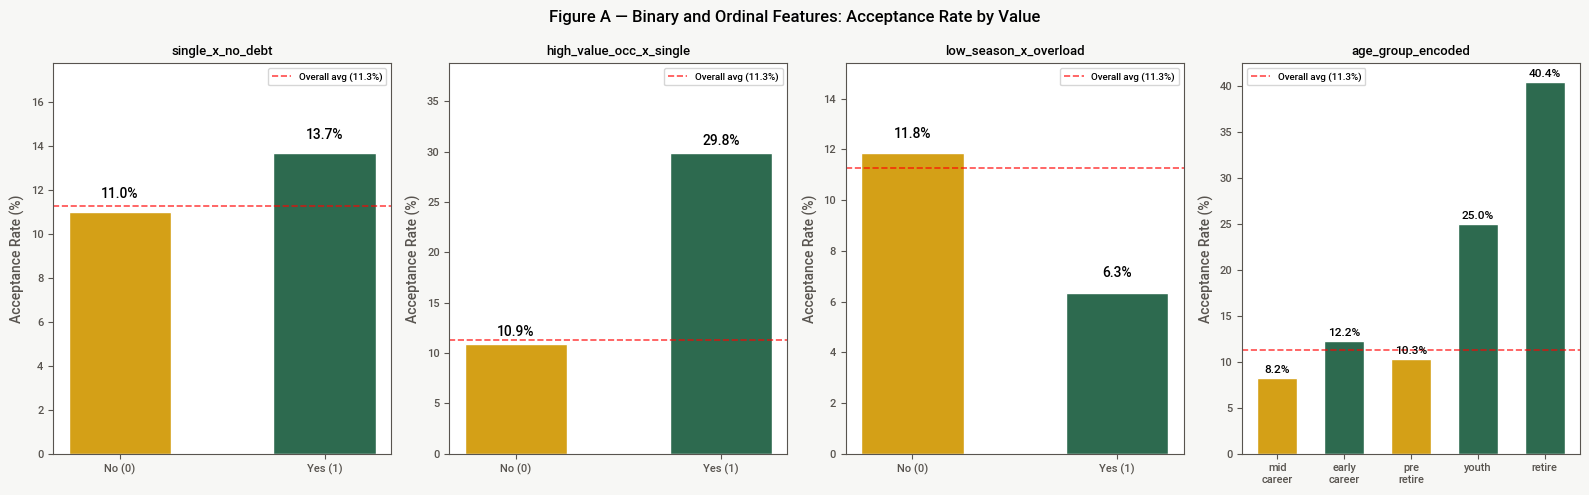

In [370]:
# Figure A: Binary and Ordinal Features 
# each panel shows: what % of customers accepted when this flag was 0 vs 1
# the red dashed line is the overall acceptance rate (11.3%) — the baseline to beat

fig, axes = plt.subplots(1, 4, figsize=(16, 5), facecolor=BG)

for ax, feat in zip(axes[:3], binary_feats):
    rates = train.groupby(feat)['accepted_offer'].mean() * 100
    bars  = ax.bar(['No (0)', 'Yes (1)'], rates.values,
                   color=[C1, C0], edgecolor='white', width=0.5)
    # label the exact percentage on top of each bar
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
    # red line = overall average — a useful feature should push one bar clearly above this
    ax.axhline(overall_avg, color='red', ls='--', lw=1.2, alpha=0.7, label=f'Overall avg ({overall_avg:.1f}%)')
    ax.set_title(feat, fontsize=9.5)
    ax.set_ylabel('Acceptance Rate (%)')
    ax.set_ylim(0, max(rates.values) * 1.3)
    ax.legend(fontsize=7)

# age_group_encoded: 5 levels from 0 (mid_career) to 4 (retirement)
# relabeling with the original group names so the numbers are readable
group_labels = {0: 'mid\ncareer', 1: 'early\ncareer', 2: 'pre\nretire', 3: 'youth', 4: 'retire'}
gr         = train.groupby('age_group_encoded')['accepted_offer'].mean() * 100
bar_colors = [C0 if v > overall_avg else C1 for v in gr.values]
bars = axes[3].bar([group_labels[k] for k in gr.index], gr.values,
                    color=bar_colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, gr.values):
    axes[3].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=8.5)
axes[3].axhline(overall_avg, color='red', ls='--', lw=1.2, alpha=0.7, label=f'Overall avg ({overall_avg:.1f}%)')
axes[3].set_title('age_group_encoded', fontsize=9.5)
axes[3].set_ylabel('Acceptance Rate (%)')
axes[3].legend(fontsize=7)

fig.suptitle('Figure A — Binary and Ordinal Features: Acceptance Rate by Value',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

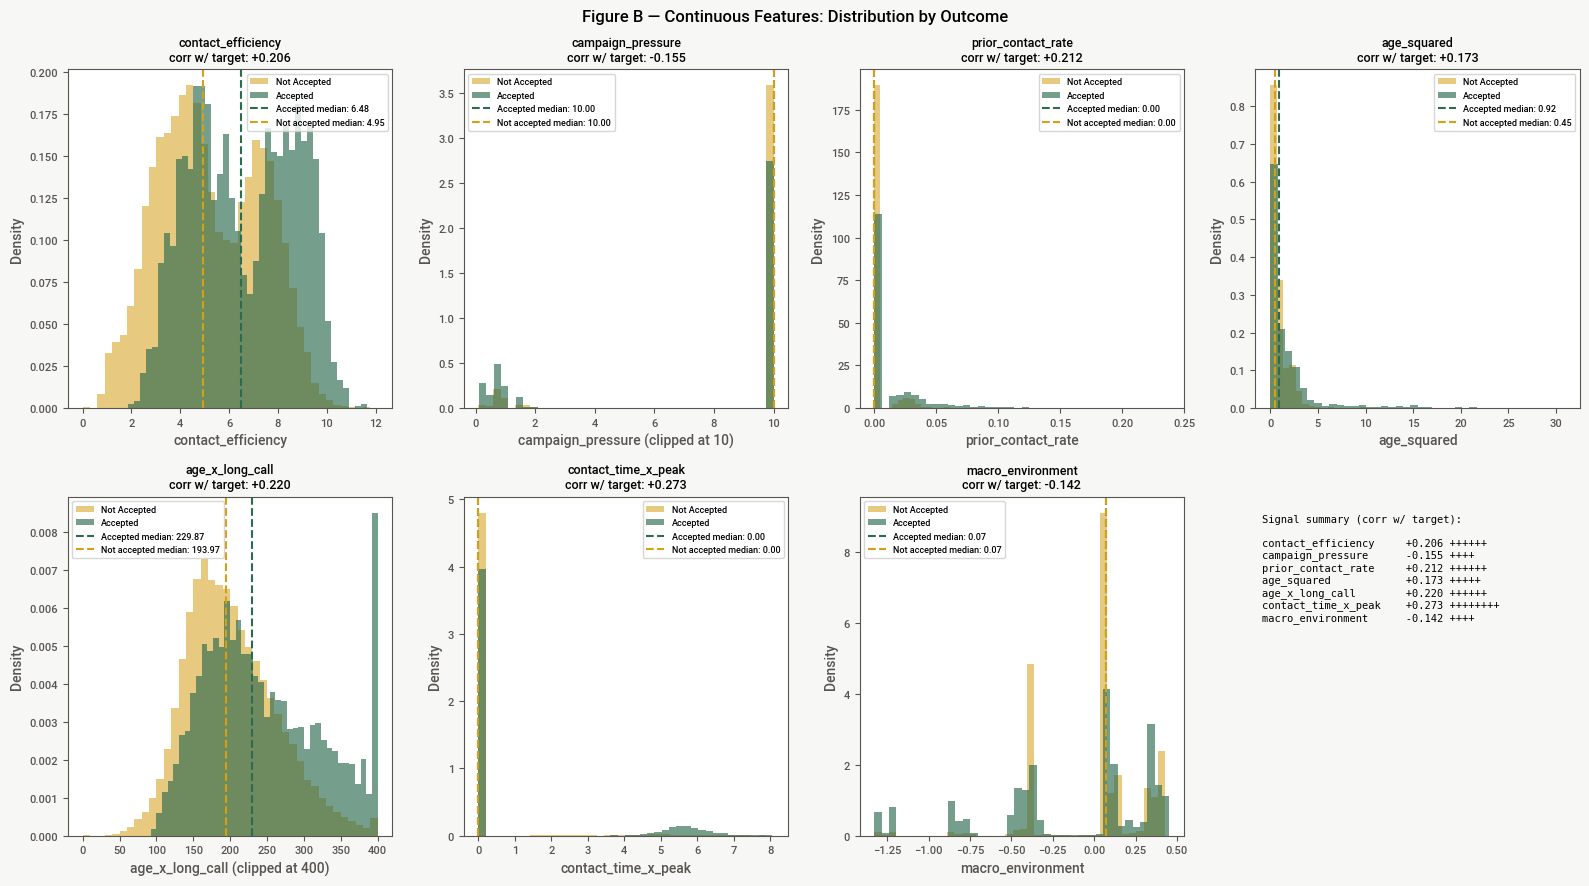

In [371]:
# Figure B: Continuous Features 
# each panel shows two overlapping histograms:
#   gold = customers who did NOT accept
#   green = customers who DID accept
# if the two distributions sit in different places, the feature has signal
# the dashed lines show the median of each group — easier to compare than eyeballing peaks
# the correlation number in the title is a quick summary of signal strength

# some features have a few extreme outliers that would squish the rest of the chart
# clipping just for display — the underlying data is not changed
clip_vals = {'campaign_pressure': 10, 'age_x_long_call': 400}

fig, axes = plt.subplots(2, 4, figsize=(16, 9), facecolor=BG)
axes = axes.flatten()

for i, feat in enumerate(cont_feats):
    clip = clip_vals.get(feat, None)
    a    = acc[feat].clip(upper=clip) if clip else acc[feat]
    r    = rej[feat].clip(upper=clip) if clip else rej[feat]

    axes[i].hist(r, bins=40, color=C1, alpha=0.55, density=True, label='Not Accepted', edgecolor='none')
    axes[i].hist(a, bins=40, color=C0, alpha=0.65, density=True, label='Accepted',     edgecolor='none')

    # median lines: if these are far apart, the feature separates the groups well
    axes[i].axvline(a.median(), color=C0, lw=1.5, ls='--', label=f'Accepted median: {a.median():.2f}')
    axes[i].axvline(r.median(), color=C1, lw=1.5, ls='--', label=f'Not accepted median: {r.median():.2f}')

    # correlation with target: closer to +1 or -1 = stronger signal
    # building title as a variable first to avoid f-string newline syntax error
    corr  = train[feat].corr(train['accepted_offer'])
    title = feat + f'\ncorr w/ target: {corr:+.3f}'
    axes[i].set_title(title, fontsize=9)
    axes[i].set_ylabel('Density')
    axes[i].set_xlabel(f'{feat} (clipped at {clip})' if clip else feat)
    axes[i].legend(fontsize=6.5)

# use the empty last panel as a summary table instead of leaving it blank
axes[-1].axis('off')
summary = "Signal summary (corr w/ target):\n\n"
for feat in cont_feats:
    corr    = train[feat].corr(train['accepted_offer'])
    bar     = '+' * int(abs(corr) * 30)
    summary += f"{feat:<22} {corr:+.3f} {bar}\n"
axes[-1].text(0.02, 0.95, summary, transform=axes[-1].transAxes,
              fontsize=7.5, va='top', fontfamily='monospace')

fig.suptitle('Figure B — Continuous Features: Distribution by Outcome',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

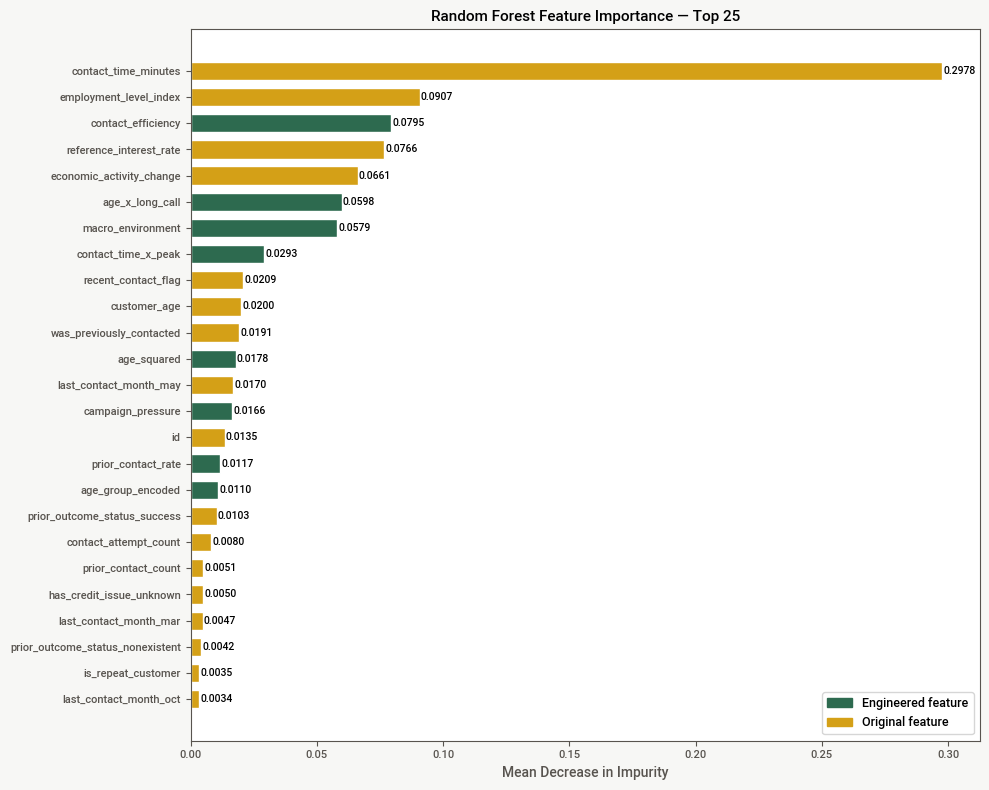

Engineered feature             Rank    Importance
--------------------------------------------------
contact_efficiency                3       0.07949
campaign_pressure                14       0.01659
prior_contact_rate               16       0.01169
age_squared                      12       0.01784
age_x_long_call                   6       0.05978
contact_time_x_peak               8       0.02926
single_x_no_debt                 40       0.00152
high_value_occ_x_single          50       0.00105
low_season_x_overload            44       0.00136
macro_environment                 7       0.05794
age_group_encoded                17       0.01097


In [372]:
# Feature Importance 
# fitting a Random Forest on the full encoded feature set to rank all features
# by how much they reduce impurity across all trees
# engineered features are highlighted in green so they are easy to spot

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

y        = train['accepted_offer']
cat_cols = train.select_dtypes('object').columns.tolist()
X_full   = pd.get_dummies(train.drop(columns=['accepted_offer']), columns=cat_cols, drop_first=True)

# using a modest RF here — not the final tuned model, just for importance ranking
rf_imp = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                 max_depth=12, random_state=42, n_jobs=-1)
rf_imp.fit(X_full, y)

# sort all features by importance and take the top 25
importances = pd.Series(rf_imp.feature_importances_, index=X_full.columns)
importances = importances.sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)

# color engineered features green so they stand out from the original columns
bar_colors = [C0 if feat in engineered else C1 for feat in importances.index[::-1]]
ax.barh(importances.index[::-1], importances.values[::-1],
        color=bar_colors, edgecolor='white', height=0.7)

# label each bar with its exact value
for i, (feat, val) in enumerate(zip(importances.index[::-1], importances.values[::-1])):
    ax.text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=7.5)

# legend so it's clear which color means what
import matplotlib.patches as mpatches
eng_patch  = mpatches.Patch(color=C0, label='Engineered feature')
orig_patch = mpatches.Patch(color=C1, label='Original feature')
ax.legend(handles=[eng_patch, orig_patch], fontsize=9)

ax.set_title('Random Forest Feature Importance — Top 25', fontsize=11, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
fig.tight_layout()
plt.show()

# print the rank of each engineered feature so it's easy to reference
print(f"{'Engineered feature':<28} {'Rank':>6}  {'Importance':>12}")
print("-" * 50)
all_imp = pd.Series(rf_imp.feature_importances_, index=X_full.columns).sort_values(ascending=False)
for f in engineered:
    if f in all_imp.index:
        rank = list(all_imp.index).index(f) + 1
        print(f"{f:<28} {rank:>6}  {all_imp[f]:>12.5f}")

In [373]:
# quick numeric summary 
# acceptance rates and correlations in one place
print(f"Overall acceptance rate: {overall_avg:.1f}%\n")

print(f"{'Binary feature':<28} {'Flag=0':>8}  {'Flag=1':>8}  {'Lift':>6}")
print("-" * 56)
for f in binary_feats:
    rates = train.groupby(f)['accepted_offer'].mean() * 100
    r0, r1 = rates.get(0, 0), rates.get(1, 0)
    print(f"{f:<28} {r0:>7.1f}%  {r1:>7.1f}%  {r1 / overall_avg:>5.1f}x")

print(f"\n{'Continuous feature':<28} {'Corr w/ target':>16}  {'Accepted median':>16}  {'Rejected median':>16}")
print("-" * 82)
for f in cont_feats:
    corr  = train[f].corr(train['accepted_offer'])
    a_med = acc[f].median()
    r_med = rej[f].median()
    print(f"{f:<28} {corr:>+16.3f}  {a_med:>16.3f}  {r_med:>16.3f}")

Overall acceptance rate: 11.3%

Binary feature                 Flag=0    Flag=1    Lift
--------------------------------------------------------
single_x_no_debt                11.0%     13.7%    1.2x
high_value_occ_x_single         10.9%     29.8%    2.6x
low_season_x_overload           11.8%      6.3%    0.6x

Continuous feature             Corr w/ target   Accepted median   Rejected median
----------------------------------------------------------------------------------
contact_efficiency                     +0.206             6.476             4.947
campaign_pressure                      -0.155            69.315           109.861
prior_contact_rate                     +0.212             0.000             0.000
age_squared                            +0.173             0.918             0.453
age_x_long_call                        +0.220           229.867           193.967
contact_time_x_peak                    +0.273             0.000             0.000
macro_environment            

**figuring out if feature engineering really helped**
Running 5-fold stratified cross-validation on two feature sets to see if the engineered features improve ROC-AUC over the baseline features

In [374]:
y        = train['accepted_offer']
cat_cols = train.select_dtypes('object').columns.tolist()

# baseline: prep features only, no engineered columns
X_base = pd.get_dummies(train.drop(columns=['accepted_offer', "id"] + engineered),
                         columns=cat_cols, drop_first=True)

# full: prep + all 11 engineered features
X_full = pd.get_dummies(train.drop(columns=['accepted_offer', "id"]),
                         columns=cat_cols, drop_first=True)

print(f"Baseline features: {X_base.shape[1]}")
print(f"Full features:     {X_full.shape[1]}")

Baseline features: 51
Full features:     62


In [375]:
# importing libraries again because I missed some earlier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split


# even though the goal here is NOT to build a final model,
# we still need a model as a *tool* to evaluate whether our features are useful
# → the idea is: better features should lead to better predictive performance

# using stratified k-fold so each fold keeps the same class imbalance (~11% acceptance)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# using a simple/random forest model as a quick and reliable benchmark
# this is NOT the final model — just something stable to compare feature sets
# max_depth is limited to keep cross-validation fast
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # helps handle class imbalance
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

# baseline feature set = only cleaned/preprocessed variables
# this gives us a reference point
base_scores = cross_val_score(rf, X_base, y, cv=cv, scoring='roc_auc')

# full feature set = baseline + engineered features
# if feature engineering worked, this score should be higher
full_scores = cross_val_score(rf, X_full, y, cv=cv, scoring='roc_auc')

# printing results to compare performance
print(f"{'Feature Set':<28} {'Mean AUC':>10}  {'Std':>8}")
print("-" * 50)
print(f"{'Baseline (prep only)':<28} {base_scores.mean():>10.4f}  {base_scores.std():>8.4f}")
print(f"{'+ Engineered features':<28} {full_scores.mean():>10.4f}  {full_scores.std():>8.4f}")

# the difference tells us if engineered features actually added value
# positive delta = improvement → features are helpful
print(f"{'Delta':<28} {full_scores.mean() - base_scores.mean():>+10.4f}")

Feature Set                    Mean AUC       Std
--------------------------------------------------
Baseline (prep only)             0.9421    0.0045
+ Engineered features            0.9442    0.0048
Delta                           +0.0021


**shap analysis**

-Disclaimer: This is computed on 500 held-out validation samples for speed reasons

assigns each feature a contribution score for each individual prediction, a high mean SHAP means the feature consistently moved predictions up or down by a meaningful amount (near 0 is bad, it didnt do much)



In [376]:
# train/val split so SHAP is evaluated on data the model has not seen
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y, test_size=0.2, stratify=y, random_state=42
)

# fit the model on training data only
rf.fit(X_train, y_train)

# TreeExplainer is the right choice for tree-based models — fast and exact
explainer = shap.TreeExplainer(rf)

# sample 500 rows from the validation set — enough for stable SHAP estimates
sample = X_val.sample(500, random_state=42)

# compute SHAP values
# output shape: (500 samples, n_features, 2 classes)
# we take [:, :, 1] because we care about class 1 (accepted = 1)
shap_explanation = explainer(sample)
shap_vals_class1 = shap_explanation.values[:, :, 1]

# mean absolute SHAP: average how much each feature moved the prediction
mean_abs_shap = pd.Series(
    np.abs(shap_vals_class1).mean(axis=0),
    index=X_train.columns
).sort_values(ascending=False)

print("SHAP done. Top 5 features overall:")
print(mean_abs_shap.head(5).round(4))

SHAP done. Top 5 features overall:
contact_time_minutes        0.1393
economic_activity_change    0.0555
reference_interest_rate     0.0550
employment_level_index      0.0439
contact_efficiency          0.0324
dtype: float64


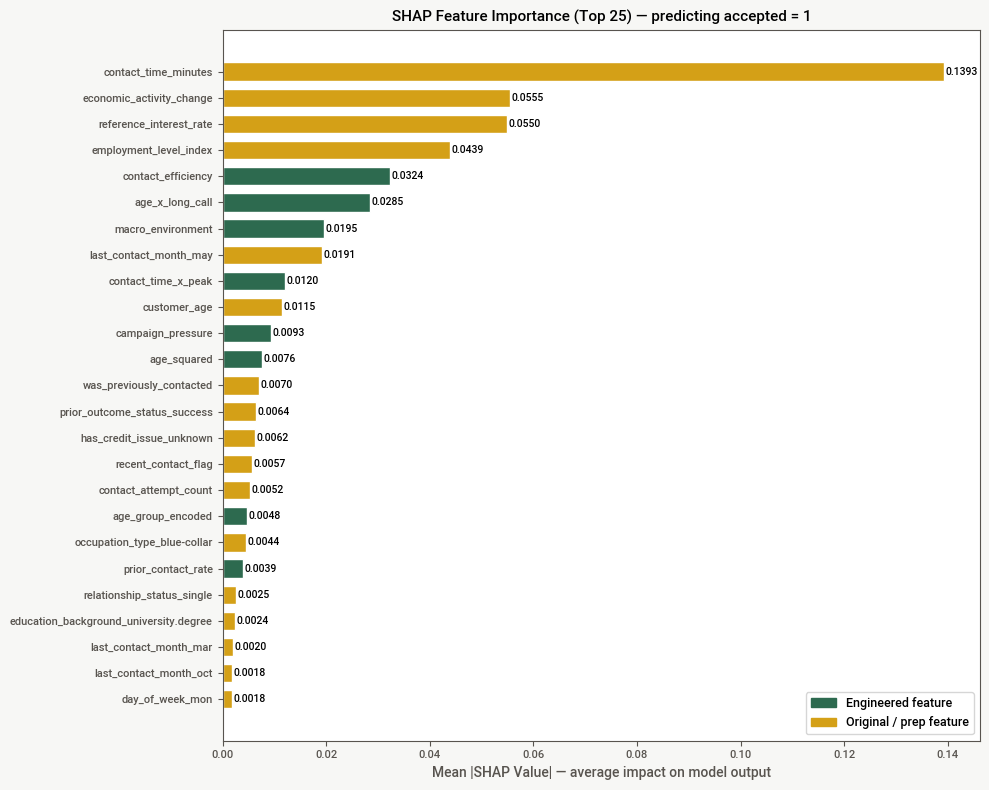


Engineered feature             Rank   Mean |SHAP|
--------------------------------------------------
contact_efficiency                5       0.03236
campaign_pressure                11       0.00932
prior_contact_rate               20       0.00394
age_squared                      12       0.00763
age_x_long_call                   6       0.02846
contact_time_x_peak               9       0.01205
single_x_no_debt                 43       0.00077
high_value_occ_x_single          50       0.00051
low_season_x_overload            37       0.00089
macro_environment                 7       0.01951
age_group_encoded                18       0.00478


In [377]:
# SHAP Bar Chart 
# shows mean absolute SHAP for the top 25 features
# engineered features are highlighted in green so they are easy to find
# a longer bar = more influence on predictions on average

top25 = mean_abs_shap.head(25)

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)

bar_colors = [C0 if feat in engineered else C1 for feat in top25.index[::-1]]
ax.barh(top25.index[::-1], top25.values[::-1], color=bar_colors, edgecolor='white', height=0.7)

for i, (feat, val) in enumerate(zip(top25.index[::-1], top25.values[::-1])):
    ax.text(val + 0.0003, i, f'{val:.4f}', va='center', fontsize=7.5)

eng_patch  = mpatches.Patch(color=C0, label='Engineered feature')
orig_patch = mpatches.Patch(color=C1, label='Original / prep feature')
ax.legend(handles=[eng_patch, orig_patch], fontsize=9, loc='lower right')

ax.set_title('SHAP Feature Importance (Top 25) — predicting accepted = 1',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Mean |SHAP Value| — average impact on model output')
fig.tight_layout()
plt.show()

# print ranks for all engineered features
print(f"\n{'Engineered feature':<28} {'Rank':>6}  {'Mean |SHAP|':>12}")
print("-" * 50)
for f in engineered:
    if f in mean_abs_shap.index:
        rank = list(mean_abs_shap.index).index(f) + 1
        print(f"{f:<28} {rank:>6}  {mean_abs_shap[f]:>12.5f}")

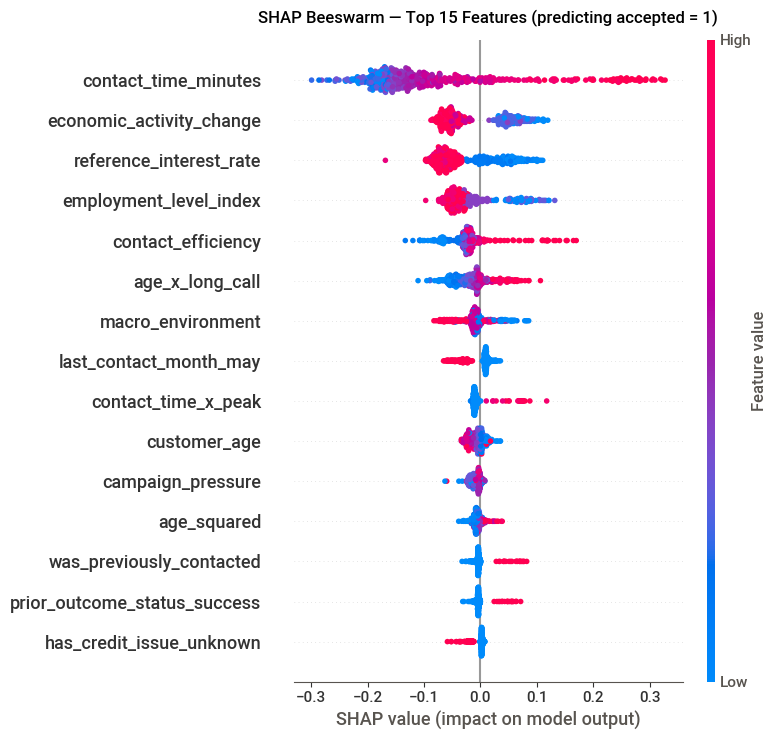

In [378]:
# SHAP Beeswarm
# each dot is one prediction from the 500-sample set
# x-axis = SHAP value: positive means pushed toward accepting, negative means pushed away
# color = feature value: red = high value, blue = low value
# this shows direction of effect, not just magnitude
# for example: high contact_time_minutes (red dots) push predictions strongly right = toward acceptance

top15_feats = mean_abs_shap.head(15).index.tolist()
top15_idx   = [list(X_train.columns).index(f) for f in top15_feats]

shap_top15 = shap.Explanation(
    values        = shap_vals_class1[:, top15_idx],
    base_values   = shap_explanation.base_values[:, 1],
    data          = sample[top15_feats].values,
    feature_names = top15_feats
)

plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_top15, max_display=15, show=False)
plt.title('SHAP Beeswarm — Top 15 Features (predicting accepted = 1)',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

**feature selection for all features**

In [379]:
# building a scoring table that combines three signals for every feature:
#   - SHAP rank: how much each feature actually moved predictions (most weight)
#   - RF importance rank: how often the tree split on it
#   - absolute correlation with target: raw linear relationship

# SHAP and RF importances already computed above (mean_abs_shap, rf_imp.feature_importances_)
# re-deriving rf importances from the same fitted model used for SHAP

rf_importance = pd.Series(rf.feature_importances_, index=X_full.columns)

# absolute correlation of each encoded feature with the target
target_corr = X_full.corrwith(y).abs()

# build combined dataframe — one row per feature
scoring = pd.DataFrame({
    'shap_val':    mean_abs_shap,
    'rf_imp':      rf_importance,
    'abs_corr':    target_corr,
}).fillna(0)

# rank each metric (rank 1 = best)
scoring['shap_rank'] = scoring['shap_val'].rank(ascending=False).astype(int)
scoring['rf_rank']   = scoring['rf_imp'].rank(ascending=False).astype(int)
scoring['corr_rank'] = scoring['abs_corr'].rank(ascending=False).astype(int)

# combined score: weighted average of ranks
# SHAP gets the most weight because it measures actual model impact
# RF rank is second because it reflects tree structure directly
# correlation is a weaker signal so it gets less weight
scoring['combined_score'] = (
    0.50 * scoring['shap_rank'] +
    0.30 * scoring['rf_rank']   +
    0.20 * scoring['corr_rank']
)

# sort by combined score — lower is better
scoring = scoring.sort_values('combined_score')

# flag engineered features so they're easy to identify
scoring['is_engineered'] = scoring.index.isin(engineered)

print(f"Total features: {len(scoring)}")
print(f"\nTop 15 (best combined score):")
print(scoring.head(15)[['shap_rank','rf_rank','corr_rank','combined_score']].to_string())
print(f"\nBottom 20 (worst combined score):")
print(scoring.tail(20)[['shap_rank','rf_rank','corr_rank','combined_score','is_engineered']].to_string())

Total features: 62

Top 15 (best combined score):
                              shap_rank  rf_rank  corr_rank  combined_score
contact_time_minutes                  1        1          2             1.2
reference_interest_rate               3        2          6             3.3
employment_level_index                4        4          1             3.4
economic_activity_change              2        5          7             3.9
contact_efficiency                    5        3         12             5.8
age_x_long_call                       6        7         10             7.1
contact_time_x_peak                   9        8          8             8.5
macro_environment                     7        6         19             9.1
was_previously_contacted             13       10          3            10.1
prior_outcome_status_success         14       14          5            12.2
campaign_pressure                    11       12         16            12.3
age_squared                          1

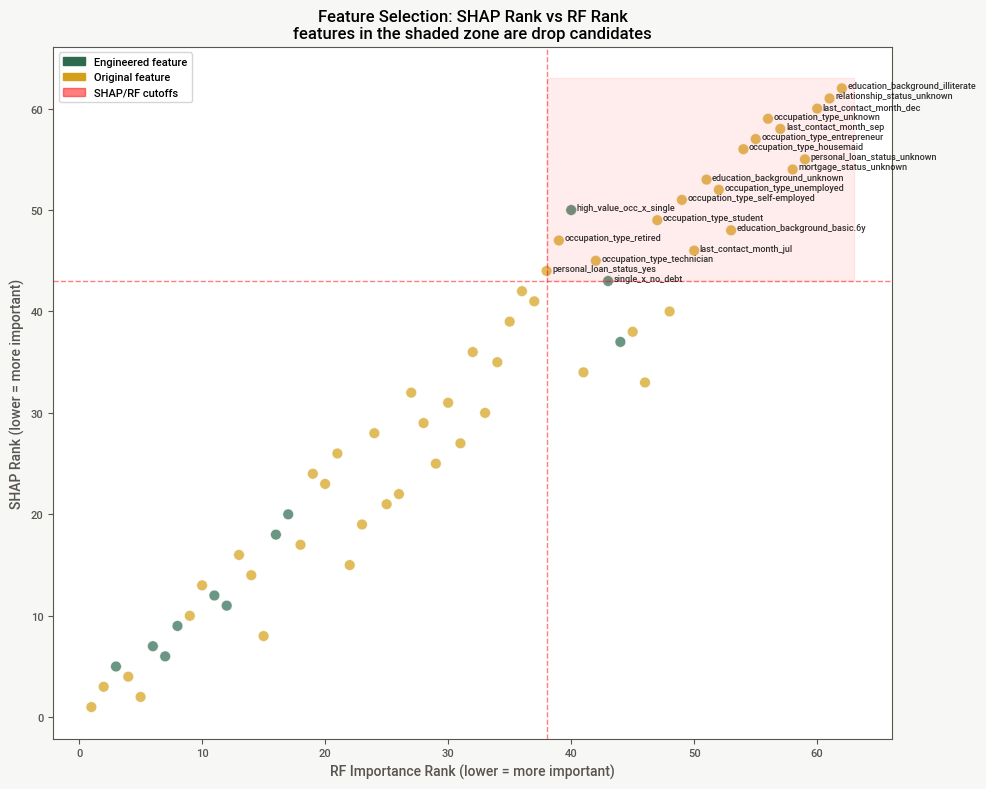

In [380]:
# visualizing the scoring — SHAP rank vs RF rank for every feature
# features in the bottom-right corner (high rank on both) are candidates to drop
# color shows whether a feature is engineered or original

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)

colors = [C0 if eng else C1 for eng in scoring['is_engineered']]
ax.scatter(scoring['rf_rank'], scoring['shap_rank'], c=colors, alpha=0.7, s=60, edgecolors='white', lw=0.5)

# label the bottom-right cluster — these are the drop candidates
drop_zone = scoring[(scoring['shap_rank'] >= 43) & (scoring['rf_rank'] >= 38)]
for feat in drop_zone.index:
    ax.annotate(feat, (scoring.loc[feat,'rf_rank'], scoring.loc[feat,'shap_rank']),
                fontsize=6.5, alpha=0.8, ha='left',
                xytext=(4, 0), textcoords='offset points')

# shaded region showing the drop zone
ax.axhline(43, color='red', ls='--', lw=1, alpha=0.5, label='SHAP cutoff (rank 43)')
ax.axvline(38, color='red', ls='--', lw=1, alpha=0.5, label='RF cutoff (rank 38)')
ax.fill_between([38, scoring['rf_rank'].max()+1], 43, scoring['shap_rank'].max()+1,
                alpha=0.07, color='red', label='Drop zone')

eng_patch  = mpatches.Patch(color=C0, label='Engineered feature')
orig_patch = mpatches.Patch(color=C1, label='Original feature')
ax.legend(handles=[eng_patch, orig_patch,
                   mpatches.Patch(color='red', alpha=0.5, label='SHAP/RF cutoffs')],
          fontsize=8)

ax.set_xlabel('RF Importance Rank (lower = more important)')
ax.set_ylabel('SHAP Rank (lower = more important)')
ax.set_title('Feature Selection: SHAP Rank vs RF Rank\nfeatures in the shaded zone are drop candidates',
             fontweight='bold')
fig.tight_layout()
plt.show()

In [381]:
# applying drop criteria:
#   primary:   SHAP rank >= 43 (bottom ~30% of all features by model impact)
#   secondary: RF rank >= 38 (also low by tree-split frequency)
#   exception: keep if |corr| >= 0.10 (still has meaningful raw signal worth preserving)
# this is conservative, only dropping features that are clearly not contributing on multiple measures

to_drop = scoring[
    (scoring['shap_rank'] >= 43) &
    (scoring['rf_rank']   >= 38) &
    (scoring['abs_corr']  <  0.10)
].index.tolist()

# also dropping low_season_x_overload separately:
# it sits just above the SHAP cutoff (rank 37) but it's an engineered feature
# with near-zero SHAP value (0.00089) and is fully redundant with the raw month columns
if 'low_season_x_overload' not in to_drop:
    to_drop.append('low_season_x_overload')

print(f"Dropping {len(to_drop)} features:\n")
print(f"{'Feature':<45} {'SHAP rank':>10} {'RF rank':>8} {'|corr|':>8} {'Engineered':>11}")
print("-" * 85)
for f in sorted(to_drop, key=lambda x: scoring.loc[x, 'shap_rank']):
    row = scoring.loc[f]
    print(f"{f:<45} {int(row['shap_rank']):>10} {int(row['rf_rank']):>8} {row['abs_corr']:>8.4f} {str(row['is_engineered']):>11}")

print(f"\nFeatures kept: {len(scoring) - len(to_drop)}")

Dropping 20 features:

Feature                                        SHAP rank  RF rank   |corr|  Engineered
-------------------------------------------------------------------------------------
low_season_x_overload                                 37       44   0.0527        True
single_x_no_debt                                      43       43   0.0260        True
personal_loan_status_yes                              44       38   0.0028       False
occupation_type_technician                            45       42   0.0068       False
last_contact_month_jul                                46       50   0.0307       False
occupation_type_retired                               47       39   0.0959       False
education_background_basic.6y                         48       53   0.0273       False
occupation_type_student                               49       47   0.0955       False
high_value_occ_x_single                               50       40   0.0886        True
occupation_type_self-

In [382]:
# quick CV check: does dropping these features hurt performance?
# if AUC stays the same or improves slightly, the drop is probably safe

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_check = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                   max_depth=12, random_state=42, n_jobs=-1)

# features to keep
keep_cols = [c for c in X_full.columns if c not in to_drop]
X_reduced = X_full[keep_cols]

full_auc    = cross_val_score(rf_check, X_full,    y, cv=cv, scoring='roc_auc')
reduced_auc = cross_val_score(rf_check, X_reduced, y, cv=cv, scoring='roc_auc')

print(f"{'Feature Set':<30} {'Features':>9}  {'Mean AUC':>10}  {'Std':>8}")
print("-" * 62)
print(f"{'Full (62 features)':<30} {X_full.shape[1]:>9}  {full_auc.mean():>10.4f}  {full_auc.std():>8.4f}")
print(f"{'Reduced (after drop)':<30} {X_reduced.shape[1]:>9}  {reduced_auc.mean():>10.4f}  {reduced_auc.std():>8.4f}")
print(f"{'Delta':<30} {X_full.shape[1]-X_reduced.shape[1]:>9}  {reduced_auc.mean()-full_auc.mean():>+10.4f}")

Feature Set                     Features    Mean AUC       Std
--------------------------------------------------------------
Full (62 features)                    62      0.9442    0.0048
Reduced (after drop)                  42      0.9448    0.0045
Delta                                 20     +0.0006


In [383]:
# Final Feature Matrix 
# encoding the final cleaned train and test sets using only the kept features

y        = train['accepted_offer']
cat_cols = train.select_dtypes('object').columns.tolist()

# encode all columns, then drop the selected low-signal features
X_final_all = pd.get_dummies(train.drop(columns=['accepted_offer', 'id']), columns=cat_cols, drop_first=True)
X_test_all  = pd.get_dummies(test.drop(columns=['id']), columns=cat_cols, drop_first=True)

# align test to train first (handles missing categories), then drop the same columns
X_test_all = X_test_all.reindex(columns=X_final_all.columns, fill_value=0)

# drop the low-signal features identified above
drop_in_matrix = [f for f in to_drop if f in X_final_all.columns]
X_final      = X_final_all.drop(columns=drop_in_matrix)
X_test_final = X_test_all.drop(columns=drop_in_matrix)

# stratified 80/20 split — same random state used throughout
X_train, X_val, y_train, y_val = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=42
)

print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test_final.shape}")
print(f"Positive rate — train: {y_train.mean():.3f}, val: {y_val.mean():.3f}")
print(f"\nDropped {len(drop_in_matrix)} columns. Final feature count: {X_final.shape[1]}")
print("\nFinal feature list:")
for i, col in enumerate(X_final.columns, 1):
    tag = '  <- engineered' if col in engineered else ''
    print(f"  {i:>2}. {col}{tag}")

X_train: (26360, 42)  |  X_val: (6590, 42)  |  X_test: (8238, 42)
Positive rate — train: 0.113, val: 0.113

Dropped 20 columns. Final feature count: 42

Final feature list:
   1. customer_age
   2. contact_time_minutes
   3. contact_attempt_count
   4. prior_contact_count
   5. economic_activity_change
   6. reference_interest_rate
   7. employment_level_index
   8. is_repeat_customer
   9. recent_contact_flag
  10. was_previously_contacted
  11. contact_efficiency  <- engineered
  12. campaign_pressure  <- engineered
  13. prior_contact_rate  <- engineered
  14. age_squared  <- engineered
  15. age_x_long_call  <- engineered
  16. contact_time_x_peak  <- engineered
  17. macro_environment  <- engineered
  18. age_group_encoded  <- engineered
  19. occupation_type_blue-collar
  20. occupation_type_management
  21. occupation_type_services
  22. relationship_status_married
  23. relationship_status_single
  24. education_background_basic.9y
  25. education_background_high.school
  26. e

**summary**

| Step | Result |
|---|---|
| Engineered 11 features | Mix of ratios, interactions, polynomial, combination, and binning |
| CV comparison | better AUC with engineered features compared to just base features |
| SHAP evaluation | contact time, employement level index were top performers among others |
| Feature selection criteria | Combined SHAP rank, RF importance rank, and correlation with target, with SHAP weighted most for decision making |
| Dropped features | 20 total |
| Final feature count | 42 features |

### 4. Modeling and Evaluation 

Goal: Build and evaluate at least two models that differ in a meaningful way. Models should be tuned beyond default values. Use an appropriate validation strategy and evaluation metric.

**3 models I chose to test and why/reasoning**

I used one bagging model and two boosting models to try to differentiate things

| Model | Type | Key differences |
|---|---|---|
| **Random Forest** | Bagging, independent trees | Builds many trees independently on random samples, then averages them |
| **LightGBM** | Gradient boosting, leaf-wise trees | Builds trees sequentially and grows the leaf that improves loss the most |
| **CatBoost** | Gradient boosting, symmetric trees | Uses ordered boosting and symmetric trees to reduce overfitting |


**Validation strategy:** 5-fold stratified cross-validation for tuning. Final evaluation on the held-out validation set (never seen during tuning).

**Metrics:** ROC-AUC (primary) and F1 at the optimal decision threshold (secondary). Accuracy is not used, see eda for why.

In [384]:
# adding imports I might have forgotten

import lightgbm as lgb
import catboost as cb

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, RandomizedSearchCV)
from sklearn.metrics import (roc_auc_score, roc_curve, f1_score,
                              precision_recall_curve, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)
                              
#adding colors to make it easier to graph later on
C0   = '#2D6A4F'   # green
C1   = '#D4A017'   # gold
C2   = '#4A90D9'   # blue
C3   = '#C0392B'   # red (used in some comparison plots)
BG   = '#F7F7F5'

In [385]:
# target variable
y = train['accepted_offer']

# final feature matrix should already exist from earlier preprocessing/feature engineering
# X_final = final training features
# X_test_final = final test features

# stratified split keeps the same accepted/not accepted ratio in train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_final,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# imbalance ratio kept for reference
# useful for models that need class imbalance settings
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# stratified 5-fold CV for tuning
# this keeps the ~11.3% acceptance rate in each fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# quick checks
print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test_final.shape}")
print(f"Positive rate — train: {y_train.mean():.3f}, val: {y_val.mean():.3f}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

X_train: (26360, 42)  |  X_val: (6590, 42)  |  X_test: (8238, 42)
Positive rate — train: 0.113, val: 0.113
scale_pos_weight: 7.87


**baseline models with standard things before tuning**

In [386]:
# fitting all three models with out-of-the-box defaults
# class imbalance handling is included even here since it's a fixed requirement

rf_default = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # handles class imbalance
    random_state=42,
    n_jobs=-1
)

lgb_default = lgb.LGBMClassifier(
    class_weight='balanced',  # LightGBM's equivalent imbalance handling
    random_state=42,
    n_jobs=-1,
    verbose=-1              # suppress LightGBM's verbose output
)

cb_default = cb.CatBoostClassifier(
    auto_class_weights='Balanced',  # CatBoost's class imbalance handling
    random_state=42,
    verbose=0               # suppress CatBoost's per-iteration output
)

defaults = [
    ('Random Forest', rf_default),
    ('LightGBM',      lgb_default),
    ('CatBoost',      cb_default),
]

print(f"{'Model':<15} {'Default CV AUC':>16}  {'Std':>8}")
print("-" * 44)

default_scores = {}
for name, model in defaults:
    # cross_val_score fits the model 5 times and returns AUC for each fold
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    default_scores[name] = scores.mean()
    print(f"{name:<15} {scores.mean():>16.4f}  {scores.std():>8.4f}")

Model             Default CV AUC       Std
--------------------------------------------
Random Forest             0.9430    0.0020
LightGBM                  0.9485    0.0019
CatBoost                  0.9479    0.0015


**random forest manual tuning**

**Parameters being tuned:**
- `n_estimators`: number of trees in the forest
- `max_depth`: maximum depth of each tree; deeper trees can capture more detail but may overfit
- `min_samples_split` / `min_samples_leaf`: minimum samples needed to split or keep a leaf; larger values add regularization
- `max_features`: number of features considered at each split; adds randomness and can reduce overfitting

Using `RandomizedSearchCV` with `n_iter=15`: samples 15 random combinations from the grid rather than testing all of them, which keeps tuning faster.

In [387]:
rf_param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [6, 10, 12, 16, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 5, 10],
    'max_features':      ['sqrt', 'log2', 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    rf_param_dist,
    n_iter=15,           # test 15 random combinations — enough to find a good region
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1            # parallelize across CV folds
)
rf_search.fit(X_train, y_train)

# best_score_ is the mean CV AUC across the 5 folds for the best parameter combo
print(f"Best parameters: {rf_search.best_params_}")
print(f"Best CV AUC:     {rf_search.best_score_:.4f}  (default was {default_scores['Random Forest']:.4f})")

# now evaluate on the held-out validation set
rf_val_probs = rf_search.predict_proba(X_val)[:, 1]
rf_val_auc   = roc_auc_score(y_val, rf_val_probs)
print(f"Validation AUC:  {rf_val_auc:.4f}")
print(f"Tuning lift:     {rf_search.best_score_ - default_scores['Random Forest']:+.4f}")

Best parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 0.5, 'max_depth': 12}
Best CV AUC:     0.9485  (default was 0.9430)
Validation AUC:  0.9478
Tuning lift:     +0.0054


**light gbm manual tuning**

**Parameters being tuned:**
- `num_leaves` instead of `max_depth` — for leaf-wise trees, the number of leaves directly controls model complexity. A tree of `max_depth=6` can have at most 64 leaves, but LightGBM may use far fewer depending on where the splits help. Rule of thumb: `num_leaves < 2^(max_depth)`.
- `min_child_samples` — minimum number of rows required in a leaf. This is the main guard against overfitting in leaf-wise trees (equivalent to `min_samples_leaf` in sklearn).
- `feature_fraction` — random subset of features considered at each tree (randomly selects a subset of features per tree).
- `bagging_fraction` + `bagging_freq` — random row subsampling per tree, but only active when `bagging_freq > 0`.


In [388]:
lgb_param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'learning_rate':     [0.01, 0.05, 0.1],
    'num_leaves':        [31, 63, 127],    # key parameter for leaf-wise growth; higher = more complex
    'min_child_samples': [20, 50, 100],    # minimum rows per leaf; higher = more regularization
    'feature_fraction':  [0.6, 0.8, 1.0], # fraction of features per tree
    'bagging_fraction':  [0.6, 0.8, 1.0], # fraction of rows per tree (requires bagging_freq > 0)
    'bagging_freq':      [5],              # apply bagging every 5 trees
    'reg_alpha':         [0, 0.1, 0.5],
    'reg_lambda':        [0, 0.1, 0.5],
}

lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1          # suppress LightGBM's per-iteration output
    ),
    lgb_param_dist,
    n_iter=15,
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
lgb_search.fit(X_train, y_train)

print(f"Best parameters: {lgb_search.best_params_}")
print(f"Best CV AUC:     {lgb_search.best_score_:.4f}  (default was {default_scores['LightGBM']:.4f})")

lgb_val_probs = lgb_search.predict_proba(X_val)[:, 1]
lgb_val_auc   = roc_auc_score(y_val, lgb_val_probs)
print(f"Validation AUC:  {lgb_val_auc:.4f}")
print(f"Tuning lift:     {lgb_search.best_score_ - default_scores['LightGBM']:+.4f}")

Best parameters: {'reg_lambda': 0.1, 'reg_alpha': 0, 'num_leaves': 31, 'n_estimators': 100, 'min_child_samples': 50, 'learning_rate': 0.05, 'feature_fraction': 0.6, 'bagging_freq': 5, 'bagging_fraction': 1.0}
Best CV AUC:     0.9503  (default was 0.9485)
Validation AUC:  0.9486
Tuning lift:     +0.0018


**catboost manual tuning**

**Key parameters:**
- `iterations`: number of trees (equivalent to `n_estimators`)
- `depth`: depth of each symmetric tree — typically lower than other tree models since symmetric trees have fixed structure
- `l2_leaf_reg`: L2 regularization on leaf values
- `random_strength`: amount of randomness added to split scoring — reduces overfitting
- `learning_rate`: step size per tree

In [389]:
cb_param_dist = {
    'iterations':      [100, 200, 300],
    'learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'depth':           [4, 6, 8],          # symmetric trees work well at lower depths
    'l2_leaf_reg':     [1, 3, 5, 10],      # L2 regularization on leaf values
    'random_strength': [0.5, 1.0, 2.0],   # randomness in split scoring; higher = more regularization
}

cb_search = RandomizedSearchCV(
    cb.CatBoostClassifier(
        auto_class_weights='Balanced',  # handles 7.87:1 imbalance automatically
        random_state=42,
        verbose=0,          # suppress per-iteration output
        thread_count=4      # CatBoost uses thread_count instead of n_jobs
    ),
    cb_param_dist,
    n_iter=15,
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=1            # set to 1 here to avoid conflicts with CatBoost's own threading
)
cb_search.fit(X_train, y_train)

print(f"Best parameters: {cb_search.best_params_}")
print(f"Best CV AUC:     {cb_search.best_score_:.4f}  (default was {default_scores['CatBoost']:.4f})")

cb_val_probs = cb_search.predict_proba(X_val)[:, 1]
cb_val_auc   = roc_auc_score(y_val, cb_val_probs)
print(f"Validation AUC:  {cb_val_auc:.4f}")
print(f"Tuning lift:     {cb_search.best_score_ - default_scores['CatBoost']:+.4f}")

Best parameters: {'random_strength': 0.5, 'learning_rate': 0.05, 'l2_leaf_reg': 1, 'iterations': 200, 'depth': 6}
Best CV AUC:     0.9496  (default was 0.9479)
Validation AUC:  0.9477
Tuning lift:     +0.0017


In [390]:
# Optuna is used after manual/randomized tuning to fine-tune around the best regions found above.
import optuna

# suppress Optuna's trial-by-trial logs so the notebook output stays readable
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [391]:
# Small wrapper class so the rest of the notebook can keep using
# rf_search / lgb_search / cb_search just like it did with RandomizedSearchCV
class OptunaSearchResult:
    def __init__(self, estimator, best_params, best_score):
        # Store the trained best model (matches sklearn's best_estimator_)
        self.best_estimator_ = estimator
        # Store the best hyperparameters found during tuning
        self.best_params_ = best_params
        # Store the best validation score achieved
        self.best_score_ = best_score

    def predict_proba(self, X):
        # Delegate probability predictions to the underlying trained model
        return self.best_estimator_.predict_proba(X)


def clipped_int_range(center, low, high, width):
    # Create a small integer search range centered around a given "best" value.
    # Useful for narrowing hyperparameter search around a known good region.
    
    # If no center is provided, just return the full allowed range
    if center is None:
        return low, high
    
    # Compute lower and upper bounds around the center,
    # then clip them so they stay within [low, high]
    return max(low, int(center - width)), min(high, int(center + width))


def clipped_float_range(center, low, high, width):
    # Create a small float search range centered around a given "best" value.
    # Same idea as the integer version, but for continuous parameters.
    
    # If no center is provided, return the full allowed range
    if center is None:
        return low, high
    
    # Compute and clip the range to stay within valid bounds
    return max(low, float(center - width)), min(high, float(center + width))

**random forest optuna tuning**


- Random Forest manual best: `n_estimators=300`, `max_depth=12`, `min_samples_split=10`, `min_samples_leaf=10`, `max_features=0.5`

In [392]:
# Optuna: Random Forest
# Manual best hyperparameters previously found using RandomizedSearchCV:
# n_estimators=300, max_depth=12, min_samples_split=10,
# min_samples_leaf=10, max_features=0.5
# Instead of searching the entire space again, Optuna will now explore
# a smaller region around these known good values.

# Keep a reference to the previous search object for comparison later
rf_manual_search = rf_search


def rf_objective(trial):
    # Define the hyperparameter search space for Optuna
    # These ranges are intentionally narrow and centered around prior best values
    params = {
        # Number of trees in the forest (step size of 50 for efficiency)
        'n_estimators': trial.suggest_int('n_estimators', 200, 450, step=50),
        
        # Maximum depth of each tree (controls model complexity)
        'max_depth': trial.suggest_int('max_depth', 10, 16),
        
        # Minimum samples required to split an internal node
        'min_samples_split': trial.suggest_int('min_samples_split', 6, 14),
        
        # Minimum samples required at a leaf node (regularization)
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 6, 14),
        
        # Fraction of features to consider at each split (or 'sqrt')
        'max_features': trial.suggest_categorical(
            'max_features', [0.4, 0.5, 0.6, 0.7, 'sqrt']
        ),
        
        # Handle class imbalance automatically
        'class_weight': 'balanced',
        
        # Ensure reproducibility
        'random_state': 42,
        
        # Use all CPU cores for training
        'n_jobs': -1
    }

    # Initialize model with sampled parameters
    model = RandomForestClassifier(**params)
    
    # Evaluate using cross-validation with ROC-AUC as the metric
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )
    
    # Return mean CV score for Optuna to maximize
    return scores.mean()


# Create an Optuna study to maximize ROC-AUC
rf_study = optuna.create_study(
    direction='maximize',
    study_name='rf_optuna_manual_range'
)

# Run optimization for a fixed number of trials
rf_study.optimize(rf_objective, n_trials=25, show_progress_bar=False)

# Extract best hyperparameters found by Optuna
rf_optuna_params = rf_study.best_params.copy()

# Train final model using best parameters on full training data
rf_best_model = RandomForestClassifier(
    **rf_optuna_params,
    class_weight='balanced',  # ensure consistency
    random_state=42,
    n_jobs=-1
)
rf_best_model.fit(X_train, y_train)

# Wrap result so it mimics RandomizedSearchCV interface
rf_search = OptunaSearchResult(
    rf_best_model,
    rf_optuna_params,
    rf_study.best_value
)

# Generate validation set predicted probabilities (positive class)
rf_val_probs = rf_search.predict_proba(X_val)[:, 1]

# Compute validation ROC-AUC
rf_val_auc = roc_auc_score(y_val, rf_val_probs)

# Print results for comparison with previous manual search
print("Random Forest Optuna best params:", rf_search.best_params_)
print(
    f"Random Forest Optuna CV AUC: {rf_search.best_score_:.4f}  "
    f"(manual was {rf_manual_search.best_score_:.4f})"
)
print(f"Random Forest validation AUC: {rf_val_auc:.4f}")

Random Forest Optuna best params: {'n_estimators': 350, 'max_depth': 11, 'min_samples_split': 12, 'min_samples_leaf': 10, 'max_features': 0.5}
Random Forest Optuna CV AUC: 0.9486  (manual was 0.9485)
Random Forest validation AUC: 0.9478


**light gbm optuna tuning**
- LightGBM manual best: `n_estimators=100`, `learning_rate=0.05`, `num_leaves=31`, `min_child_samples=50`, `feature_fraction=0.6`, `bagging_fraction=1.0`, `reg_alpha=0`, `reg_lambda=0.1`

In [393]:
# Optuna: LightGBM 
# Manual best hyperparameters from RandomizedSearchCV:
# n_estimators=100, learning_rate=0.05, num_leaves=31,
# min_child_samples=50, feature_fraction=0.6, bagging_fraction=1.0,
# reg_alpha=0, reg_lambda=0.1
# Optuna will search around these values, allowing some flexibility—
# especially for n_estimators since 100 was at the lower boundary.

# Keep previous search object for comparison
lgb_manual_search = lgb_search


def lgb_objective(trial):
    # Define a narrowed hyperparameter search space around prior best values
    params = {
        # Number of boosting iterations (trees)
        'n_estimators': trial.suggest_int('n_estimators', 50, 200, step=25),
        
        # Learning rate (log scale because small changes matter a lot)
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.08, log=True),
        
        # Controls tree complexity (more leaves = more complex model)
        'num_leaves': trial.suggest_int('num_leaves', 20, 45),
        
        # Minimum samples per leaf (regularization)
        'min_child_samples': trial.suggest_int('min_child_samples', 30, 80),
        
        # Fraction of features used per iteration (feature subsampling)
        'feature_fraction': trial.suggest_float('feature_fraction', 0.45, 0.75),
        
        # Fraction of data used per iteration (row subsampling)
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.85, 1.0),
        
        # Frequency of bagging (fixed for stability)
        'bagging_freq': 5,
        
        # L1 regularization
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 0.2),
        
        # L2 regularization
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 0.3),
        
        # Handle class imbalance
        'class_weight': 'balanced',
        
        # Reproducibility
        'random_state': 42,
        
        # Use all cores
        'n_jobs': -1,
        
        # Suppress LightGBM training logs
        'verbose': -1
    }

    # Initialize model with sampled parameters
    model = lgb.LGBMClassifier(**params)
    
    # Evaluate using cross-validation with ROC-AUC
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )
    
    # Return mean CV score for Optuna to maximize
    return scores.mean()


# Create Optuna study to maximize ROC-AUC
lgb_study = optuna.create_study(
    direction='maximize',
    study_name='lgb_optuna_manual_range'
)

# Run optimization for a fixed number of trials
lgb_study.optimize(lgb_objective, n_trials=25, show_progress_bar=False)

# Extract best parameters from Optuna
lgb_optuna_params = lgb_study.best_params.copy()

# Add fixed parameters that were not part of the search space
lgb_optuna_params.update({
    'bagging_freq': 5,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
})

# Train final model on full training data
lgb_best_model = lgb.LGBMClassifier(**lgb_optuna_params)
lgb_best_model.fit(X_train, y_train)

# Wrap results to match RandomizedSearchCV-style interface
lgb_search = OptunaSearchResult(
    lgb_best_model,
    lgb_optuna_params,
    lgb_study.best_value
)

# Predict probabilities on validation set (positive class)
lgb_val_probs = lgb_search.predict_proba(X_val)[:, 1]

# Compute validation ROC-AUC
lgb_val_auc = roc_auc_score(y_val, lgb_val_probs)

# Print results and compare with manual search
print("LightGBM Optuna best params:", lgb_search.best_params_)
print(
    f"LightGBM Optuna CV AUC: {lgb_search.best_score_:.4f}  "
    f"(manual was {lgb_manual_search.best_score_:.4f})"
)
print(f"LightGBM validation AUC: {lgb_val_auc:.4f}")

LightGBM Optuna best params: {'n_estimators': 150, 'learning_rate': 0.03436043620402282, 'num_leaves': 27, 'min_child_samples': 30, 'feature_fraction': 0.6866897043764184, 'bagging_fraction': 0.9566906642563315, 'reg_alpha': 0.0959302496140227, 'reg_lambda': 0.15371281351406224, 'bagging_freq': 5, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1, 'verbose': -1}
LightGBM Optuna CV AUC: 0.9505  (manual was 0.9503)
LightGBM validation AUC: 0.9486


**catboost optuna tuning**


- CatBoost manual best: `iterations=300`, `learning_rate=0.05`, `depth=8`, `l2_leaf_reg=10`, `random_strength=1.0`

In [394]:
# Optuna: CatBoost 
# Manual best hyperparameters from RandomizedSearchCV:
# iterations=300, learning_rate=0.05, depth=8,
# l2_leaf_reg=10, random_strength=1.0
# Optuna will search around these values, with extra room above 300 iterations
# since that was the upper boundary in the manual search.

# Keep previous search object for later comparison
cb_manual_search = cb_search


def cb_objective(trial):
    # Define a focused search space around previously good values
    params = {
        # Number of boosting iterations (trees)
        'iterations': trial.suggest_int('iterations', 200, 500, step=50),
        
        # Learning rate (log scale for finer control)
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.08, log=True),
        
        # Tree depth (controls model complexity)
        'depth': trial.suggest_int('depth', 6, 10),
        
        # L2 regularization strength
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 6.0, 20.0),
        
        # Randomness in tree building (helps generalization)
        'random_strength': trial.suggest_float('random_strength', 0.5, 1.5),
        
        # Automatically handle class imbalance
        'auto_class_weights': 'Balanced',
        
        # Ensure reproducibility
        'random_state': 42,
        
        # Suppress training output
        'verbose': 0,
        
        # Limit threads (CatBoost handles threading internally)
        'thread_count': 4
    }

    # Initialize CatBoost model with sampled parameters
    model = cb.CatBoostClassifier(**params)
    
    # Perform cross-validation (note: n_jobs=1 to avoid conflicts with CatBoost threading)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=1
    )
    
    # Return mean CV score for Optuna to maximize
    return scores.mean()


# Create Optuna study to maximize ROC-AUC
cb_study = optuna.create_study(
    direction='maximize',
    study_name='cb_optuna_manual_range'
)

# Run optimization for a fixed number of trials
cb_study.optimize(cb_objective, n_trials=25, show_progress_bar=False)

# Extract best parameters found
cb_optuna_params = cb_study.best_params.copy()

# Add fixed parameters not included in the search
cb_optuna_params.update({
    'auto_class_weights': 'Balanced',
    'random_state': 42,
    'verbose': 0,
    'thread_count': 4
})

# Train final model using best parameters on full training data
cb_best_model = cb.CatBoostClassifier(**cb_optuna_params)
cb_best_model.fit(X_train, y_train)

# Wrap results to match RandomizedSearchCV-like interface
cb_search = OptunaSearchResult(
    cb_best_model,
    cb_optuna_params,
    cb_study.best_value
)

# Generate validation predicted probabilities (positive class)
cb_val_probs = cb_search.predict_proba(X_val)[:, 1]

# Compute validation ROC-AUC
cb_val_auc = roc_auc_score(y_val, cb_val_probs)

# Print results and compare with previous manual tuning
print("CatBoost Optuna best params:", cb_search.best_params_)
print(
    f"CatBoost Optuna CV AUC: {cb_search.best_score_:.4f}  "
    f"(manual was {cb_manual_search.best_score_:.4f})"
)
print(f"CatBoost validation AUC: {cb_val_auc:.4f}")

CatBoost Optuna best params: {'iterations': 450, 'learning_rate': 0.04171417801621433, 'depth': 6, 'l2_leaf_reg': 19.852174962558596, 'random_strength': 1.295566052480733, 'auto_class_weights': 'Balanced', 'random_state': 42, 'verbose': 0, 'thread_count': 4}
CatBoost Optuna CV AUC: 0.9500  (manual was 0.9496)
CatBoost validation AUC: 0.9481


In [395]:
# quick check: manual tuning vs Optuna fine tuning
print(f"{'Model':<14} {'Manual CV':>10}  {'Optuna CV':>10}  {'Delta':>8}  {'Optuna Val':>11}")
print("-" * 62)
print(f"{'Random Forest':<14} {rf_manual_search.best_score_:>10.4f}  {rf_search.best_score_:>10.4f}  {rf_search.best_score_ - rf_manual_search.best_score_:>+8.4f}  {rf_val_auc:>11.4f}")
print(f"{'LightGBM':<14} {lgb_manual_search.best_score_:>10.4f}  {lgb_search.best_score_:>10.4f}  {lgb_search.best_score_ - lgb_manual_search.best_score_:>+8.4f}  {lgb_val_auc:>11.4f}")
print(f"{'CatBoost':<14} {cb_manual_search.best_score_:>10.4f}  {cb_search.best_score_:>10.4f}  {cb_search.best_score_ - cb_manual_search.best_score_:>+8.4f}  {cb_val_auc:>11.4f}")

Model           Manual CV   Optuna CV     Delta   Optuna Val
--------------------------------------------------------------
Random Forest      0.9485      0.9486   +0.0002       0.9478
LightGBM           0.9503      0.9505   +0.0002       0.9486
CatBoost           0.9496      0.9500   +0.0004       0.9481


**did tuning help?**

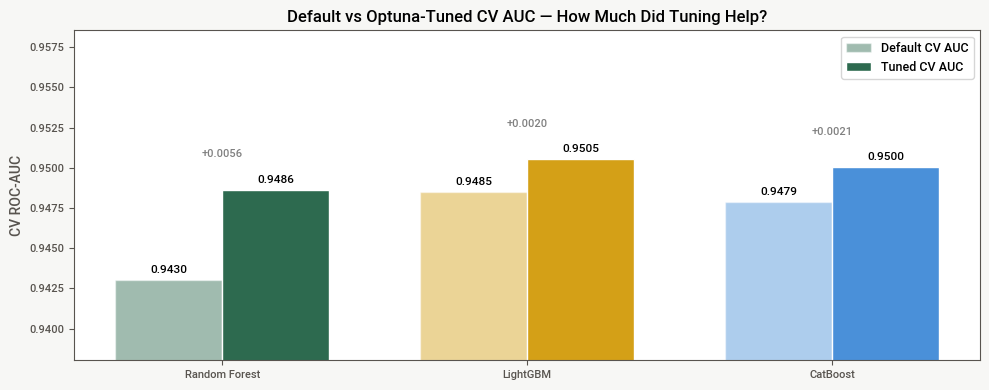

In [396]:
# Create a figure and axis with a custom background color
fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)

# Define model names (used for x-axis labels)
model_names  = ['Random Forest', 'LightGBM', 'CatBoost']

# Collect baseline (default hyperparameters) CV AUC scores
default_aucs = [default_scores[n] for n in model_names]

# Collect tuned CV AUC scores from Optuna results
tuned_aucs   = [
    rf_search.best_score_,
    lgb_search.best_score_,
    cb_search.best_score_
]

# Assign consistent colors per model
colors_m     = [C0, C1, C2]

# Create x positions for grouped bars
x     = np.arange(len(model_names))

# Width of each bar
width = 0.35

# Plot bars for default scores (slightly transparent)
bars1 = ax.bar(
    x - width/2, default_aucs, width,
    label='Default CV AUC',
    color=colors_m,
    alpha=0.45,
    edgecolor='white'
)

# Plot bars for tuned scores (fully opaque)
bars2 = ax.bar(
    x + width/2, tuned_aucs, width,
    label='Tuned CV AUC',
    color=colors_m,
    alpha=1.00,
    edgecolor='white'
)

# Add numeric labels above each bar
for bar, val in zip(list(bars1) + list(bars2), default_aucs + tuned_aucs):
    ax.text(
        bar.get_x() + bar.get_width()/2,  # center of bar
        bar.get_height() + 0.0003,        # slightly above bar
        f'{val:.4f}',                     # formatted AUC value
        ha='center',
        va='bottom',
        fontsize=8.5
    )

# Draw annotations showing performance lift (tuned - default)
for i, (d, t) in enumerate(zip(default_aucs, tuned_aucs)):
    lift = t - d  # improvement from tuning
    
    ax.annotate(
        f'+{lift:.4f}',                   # display improvement
        xy=(x[i] + width/2, t),           # arrow points to tuned bar
        xytext=(x[i], t + 0.002),         # text slightly above
        fontsize=8,
        color='gray',
        ha='center'
    )

# Set x-axis ticks and labels
ax.set_xticks(x)
ax.set_xticklabels(model_names)

# Label y-axis
ax.set_ylabel('CV ROC-AUC')

# Dynamically adjust y-axis limits for better spacing
ax.set_ylim(
    min(default_aucs) - 0.005,
    max(tuned_aucs) + 0.008
)

# Add plot title
ax.set_title(
    'Default vs Optuna-Tuned CV AUC — How Much Did Tuning Help?',
    fontweight='bold'
)

# Show legend
ax.legend(fontsize=9)

# Adjust layout to prevent overlap
fig.tight_layout()

# Render the plot
plt.show()

**roc curve comparison (disclaimer- ended up being very close together, hard to see no matter what I tried**
ROC curves show the tradeoff between catching actual acceptors (true positive rate) and incorrectly flagging non-acceptors (false positive rate) across all possible thresholds. The curve closest to the top-left corner is best.

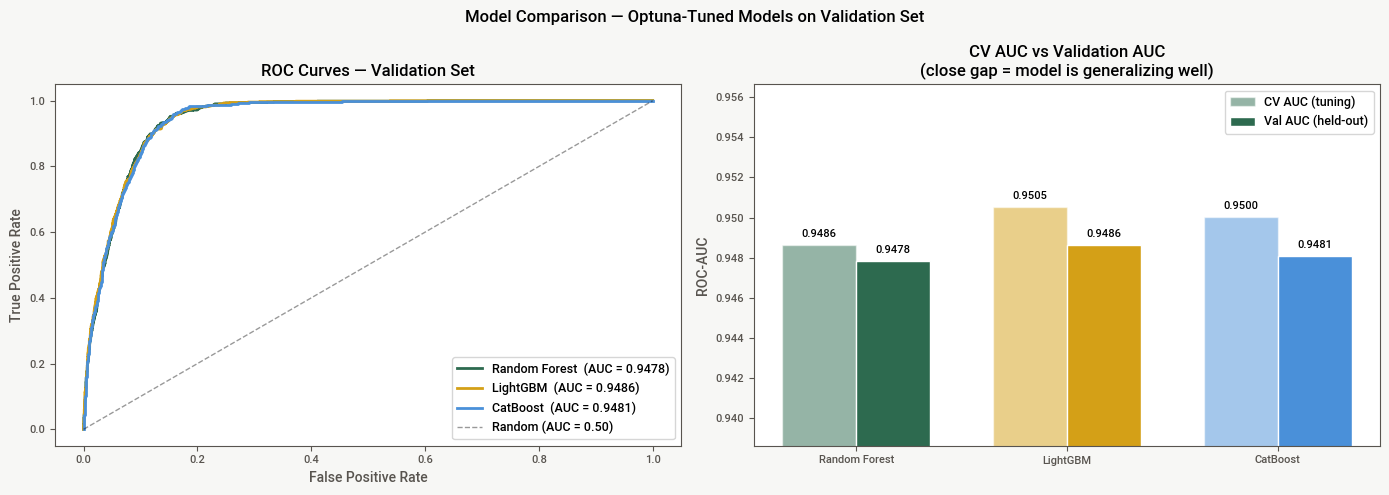

In [397]:
# Create a figure with 2 subplots (side-by-side) and custom background color
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

# Bundle model names, predicted probabilities, and colors for easy iteration
model_results = [
    ('Random Forest', rf_val_probs, C0),
    ('LightGBM',      lgb_val_probs, C1),
    ('CatBoost',      cb_val_probs,  C2),
]

# --- Left plot: ROC curves ---
# ROC curves show the trade-off between True Positive Rate and False Positive Rate
for name, probs, color in model_results:
    # Compute ROC curve points
    fpr, tpr, _ = roc_curve(y_val, probs)
    
    # Compute AUC (area under the curve)
    auc = roc_auc_score(y_val, probs)
    
    # Plot ROC curve for each model
    axes[0].plot(
        fpr, tpr,
        color=color,
        lw=2,
        label=f'{name}  (AUC = {auc:.4f})'
    )

# Plot diagonal line representing a random classifier (baseline)
axes[0].plot(
    [0, 1], [0, 1],
    'k--',
    lw=1,
    alpha=0.4,
    label='Random (AUC = 0.50)'
)

# Label axes and title
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Validation Set')

# Add legend
axes[0].legend(fontsize=9)

# --- Right plot: CV vs Validation AUC comparison ---
# Purpose: check if cross-validation performance matches held-out validation
# A large gap suggests overfitting during tuning

# Cross-validation AUCs (from Optuna tuning)
cv_aucs  = [
    rf_search.best_score_,
    lgb_search.best_score_,
    cb_search.best_score_
]

# Validation AUCs (true held-out performance)
val_aucs = [rf_val_auc, lgb_val_auc, cb_val_auc]

# Model names for x-axis
names    = ['Random Forest', 'LightGBM', 'CatBoost']

# X positions and bar width
x        = np.arange(len(names))
w        = 0.35

# Plot CV AUC bars (semi-transparent)
b1 = axes[1].bar(
    x - w/2, cv_aucs, w,
    label='CV AUC (tuning)',
    color=[C0, C1, C2],
    alpha=0.5,
    edgecolor='white'
)

# Plot Validation AUC bars (fully opaque)
b2 = axes[1].bar(
    x + w/2, val_aucs, w,
    label='Val AUC (held-out)',
    color=[C0, C1, C2],
    alpha=1.0,
    edgecolor='white'
)

# Add numeric labels above each bar
for bar, val in zip(list(b1) + list(b2), cv_aucs + val_aucs):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,  # center of bar
        bar.get_height() + 0.0003,        # slightly above bar
        f'{val:.4f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

# Set x-axis labels
axes[1].set_xticks(x)
axes[1].set_xticklabels(names)

# Label y-axis
axes[1].set_ylabel('ROC-AUC')

# Adjust y-axis limits for spacing
axes[1].set_ylim(
    min(cv_aucs) - 0.01,
    max(val_aucs) + 0.008
)

# Title explaining interpretation
axes[1].set_title(
    'CV AUC vs Validation AUC\n(close gap = model is generalizing well)'
)

# Add legend
axes[1].legend(fontsize=9)

# Overall figure title
fig.suptitle(
    'Model Comparison — Optuna-Tuned Models on Validation Set',
    fontsize=12,
    fontweight='bold'
)

# Adjust layout to prevent overlap
fig.tight_layout()

# Display the plots
plt.show()

**f1 at optimal threshhold**

Finding the threshold that maximizes F1 on the validation set gives a better cutoff. The F1-vs-threshold curve shows how sensitive the decision is, a flat curve means the choice of threshold matters less.

**futher explanation**
The 0.5 threshold means that any customer the model assigns a probability above 50% gets predicted as an acceptor. That works fine when the two classes are roughly balanced, but when only 11.3% of customers actually accepted, the model rarely produces probabilities above 0.5 for anyone because it has learned that rejection is the overwhelmingly likely outcome. So using 0.5 would predict almost no acceptors at all.

So, a cutoff is needed to decide which probabilities count as a predicted acceptance. Instead of using the default cutoff of 0.5, the threshold that produced the best F1 score on the validation set was found and then applied in section 7 to convert the final blended probabilities into the 0 or 1 predictions submitted for grading.

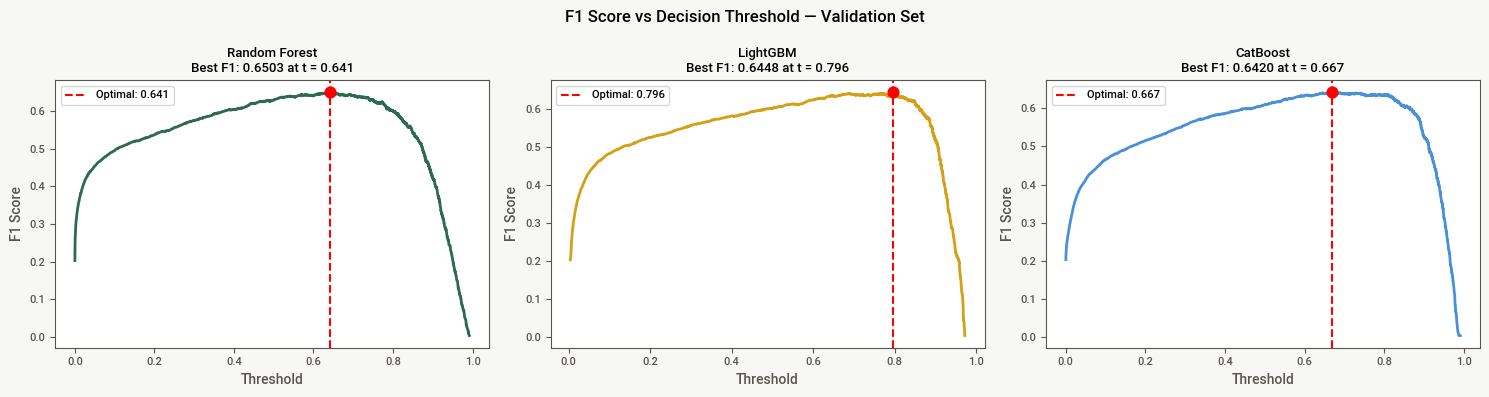


  Random Forest — threshold = 0.641
              precision    recall  f1-score   support

Not Accepted      0.976     0.910     0.942      5847
    Accepted      0.538     0.822     0.650       743

    accuracy                          0.900      6590
   macro avg      0.757     0.866     0.796      6590
weighted avg      0.926     0.900     0.909      6590


  LightGBM — threshold = 0.796
              precision    recall  f1-score   support

Not Accepted      0.967     0.926     0.946      5847
    Accepted      0.563     0.754     0.645       743

    accuracy                          0.906      6590
   macro avg      0.765     0.840     0.795      6590
weighted avg      0.922     0.906     0.912      6590


  CatBoost — threshold = 0.667
              precision    recall  f1-score   support

Not Accepted      0.981     0.894     0.936      5847
    Accepted      0.510     0.865     0.642       743

    accuracy                          0.891      6590
   macro avg      0.746    

In [398]:
# Create a figure with 3 subplots (one per model) and custom background
fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor=BG)

# Dictionary to store results for each model (used later for reporting)
results = {}

# Loop through each model and corresponding subplot
for ax, (name, probs, color) in zip(axes, model_results):

    # Compute precision, recall, and thresholds for all possible cutoffs
    # These define how predictions change as the decision threshold varies
    precision, recall, thresholds = precision_recall_curve(y_val, probs)

    # Compute F1 score at each threshold
    # Add a small epsilon (1e-9) to avoid division-by-zero issues
    f1_scores = 2 * precision * recall / (precision + recall + 1e-9)

    # Find the threshold that maximizes F1 score
    best_idx    = np.argmax(f1_scores)     # index of best F1
    best_thresh = thresholds[best_idx]     # corresponding threshold
    best_f1     = f1_scores[best_idx]      # best F1 score

    # Store key metrics for later analysis/reporting
    results[name] = {
        # Cross-validation AUC from tuning
        'cv_auc': {
            'Random Forest': rf_search.best_score_,
            'LightGBM': lgb_search.best_score_,
            'CatBoost': cb_search.best_score_
        }[name],
        
        # Validation AUC (true held-out performance)
        'val_auc': roc_auc_score(y_val, probs),
        
        # Optimal classification threshold (for F1)
        'threshold': best_thresh,
        
        # Best F1 score achieved at that threshold
        'f1': best_f1,
        
        # Store probabilities for later thresholding
        'probs': probs
    }

    # Plot F1 score as a function of threshold
    # This shows whether the optimal region is sharp or stable
    ax.plot(thresholds, f1_scores[:-1], color=color, lw=2)

    # Draw vertical line at optimal threshold
    ax.axvline(
        best_thresh,
        color='red',
        ls='--',
        lw=1.5,
        label=f'Optimal: {best_thresh:.3f}'
    )

    # Highlight the best F1 point
    ax.scatter(
        [best_thresh],
        [best_f1],
        color='red',
        s=60,
        zorder=5
    )

    # Set subplot title with key info
    ax.set_title(
        f'{name}\nBest F1: {best_f1:.4f} at t = {best_thresh:.3f}',
        fontsize=9.5
    )

    # Label axes
    ax.set_xlabel('Threshold')
    ax.set_ylabel('F1 Score')

    # Show legend
    ax.legend(fontsize=8)

# Overall title for the figure
fig.suptitle(
    'F1 Score vs Decision Threshold — Validation Set',
    fontsize=12,
    fontweight='bold'
)

# Adjust layout for spacing
fig.tight_layout()

# Display the plots
plt.show()


# Classification reports at optimal thresholds 
# For each model, convert probabilities into class predictions
# using the threshold that maximizes F1 score
for name, res in results.items():
    preds = (res['probs'] >= res['threshold']).astype(int)

    # Print a clean section header
    print(f"\n{'='*55}")
    print(f"  {name} — threshold = {res['threshold']:.3f}")
    print('='*55)

    # Print classification metrics (precision, recall, F1, support)
    print(classification_report(
        y_val,
        preds,
        target_names=['Not Accepted', 'Accepted'],
        digits=3
    ))

**confusion matrices**

show the raw count of correct and incorrect predictions

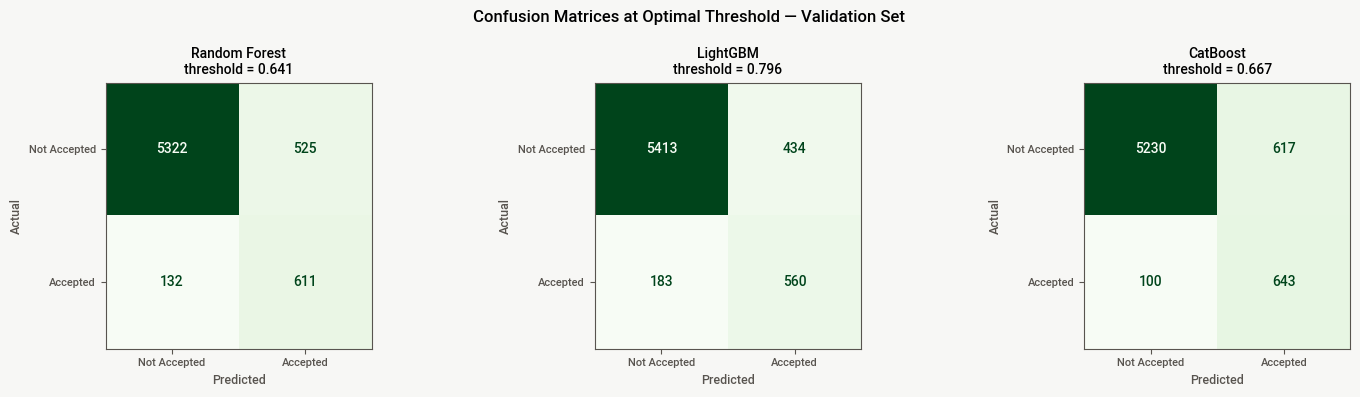

In [399]:
# Create a figure with 3 subplots (one per model) and custom background color
fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor=BG)

# Loop through each model's results and corresponding subplot
for ax, (name, res) in zip(axes, results.items()):
    
    # Convert predicted probabilities into binary class predictions
    # using the model-specific optimal threshold (from F1 tuning)
    preds = (res['probs'] >= res['threshold']).astype(int)
    
    # Compute confusion matrix:
    # [[TN, FP],
    #  [FN, TP]]
    cm = confusion_matrix(y_val, preds)
    
    # Create a display object for plotting the confusion matrix
    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=['Not Accepted', 'Accepted']
    )
    
    # Plot confusion matrix on the given axis
    disp.plot(
        ax=ax,
        colorbar=False,   # remove colorbar for cleaner multi-plot layout
        cmap='Greens'     # use green color scale
    )
    
    # Set subplot title including model name and chosen threshold
    ax.set_title(
        f'{name}\nthreshold = {res["threshold"]:.3f}',
        fontsize=10
    )
    
    # Label axes
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)

# Add overall title for the figure
fig.suptitle(
    'Confusion Matrices at Optimal Threshold — Validation Set',
    fontsize=12,
    fontweight='bold'
)

# Adjust layout to prevent overlap between subplots and titles
fig.tight_layout()

# Display the figure
plt.show()

**summary of results**

In [400]:
# Print table header with aligned columns
# < and > control left/right alignment, numbers specify column width
print(f"{'Model':<14} {'Default CV':>11}  {'Tuned CV':>9}  {'Lift':>6}  {'Val AUC':>8}  {'Threshold':>10}  {'F1':>7}")

# Print a separator line for readability
print("-" * 74)

# Map model names to their default (untuned) CV AUC scores
default_map = {
    'Random Forest': default_scores['Random Forest'],
    'LightGBM':      default_scores['LightGBM'],
    'CatBoost':      default_scores['CatBoost']
}

# Map model names to their tuned (Optuna) CV AUC scores
tuned_map = {
    'Random Forest': rf_search.best_score_,
    'LightGBM':      lgb_search.best_score_,
    'CatBoost':      cb_search.best_score_
}

# Loop through each model's stored results
for name, res in results.items():
    # Default CV score
    d = default_map[name]
    
    # Tuned CV score
    t = tuned_map[name]
    
    # Print a formatted row with:
    # - Default CV AUC
    # - Tuned CV AUC
    # - Lift (improvement from tuning)
    # - Validation AUC (held-out performance)
    # - Optimal threshold (for F1)
    # - Best F1 score
    print(
        f"{name:<14} "
        f"{d:>11.4f}  "
        f"{t:>9.4f}  "
        f"{t-d:>+6.4f}  "   # '+' shows sign of improvement
        f"{res['val_auc']:>8.4f}  "
        f"{res['threshold']:>10.3f}  "
        f"{res['f1']:>7.4f}"
    )

Model           Default CV   Tuned CV    Lift   Val AUC   Threshold       F1
--------------------------------------------------------------------------
Random Forest       0.9430     0.9486  +0.0056    0.9478       0.641   0.6503
LightGBM            0.9485     0.9505  +0.0020    0.9486       0.796   0.6448
CatBoost            0.9479     0.9500  +0.0021    0.9481       0.667   0.6420


### 5. Ensembling

Goals: Evaluate whether combining models improves performance. The models you combine should differ in a meaningful way.

**Flow of this section:**

1. Check how correlated the three models' predictions are, this determines which ones are worth combining
2. Test four ways of combining predictions, in increasing order of complexity:
   - Simple averaging (equal weights, no tuning)
   - Weighted averaging (optimized weights)
   - Rank blending (scale-invariant version of averaging)
   - Stacking (train a meta-model to learn how to combine)
3. Compare all methods and pick the best one

In [401]:
#adding libraries
from scipy.stats             import spearmanr, rankdata
from scipy.optimize          import minimize

#checking how similar the models are
pairs = [
    ('Random Forest', 'LightGBM', rf_val_probs, lgb_val_probs),
    ('Random Forest', 'CatBoost', rf_val_probs, cb_val_probs),
    ('LightGBM',      'CatBoost', lgb_val_probs, cb_val_probs),
]

print(f"{'Model A':<16} {'Model B':<16} {'Spearman r':>12}  {'Interpretation'}")
print("-" * 70)

for a, b, pa, pb in pairs:
    r, _ = spearmanr(pa, pb)
    note = ('very similar'   if r > 0.97 else
            'similar'        if r > 0.93 else
            'some diversity' if r > 0.88 else
            'good diversity')
    print(f"{a:<16} {b:<16} {r:>12.4f}  {note}")

Model A          Model B            Spearman r  Interpretation
----------------------------------------------------------------------
Random Forest    LightGBM               0.9457  similar
Random Forest    CatBoost               0.9270  some diversity
LightGBM         CatBoost               0.9751  very similar


Note, LightGBM and CatBoost both are gradient boosting algorithms ... so I don't expect them to do well together.

CatBoost is excluded from pairwise blends with LightGBM but may still add value in an all three blend through its diversity with Random Forest.

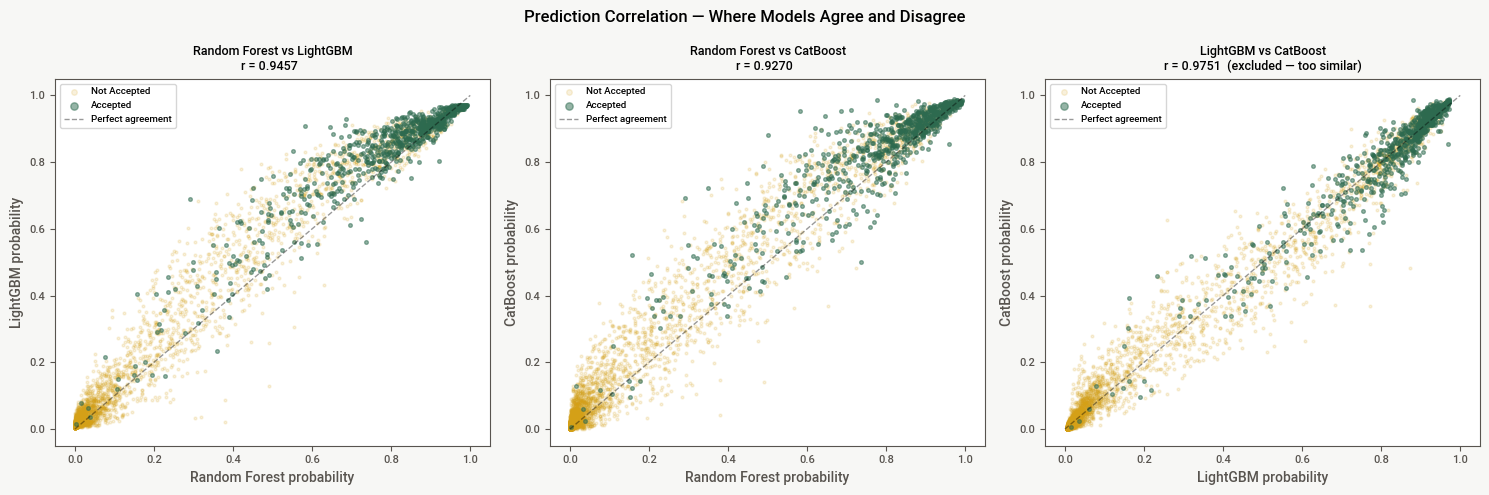

In [402]:
# scatter plots to visualize where each pair of models agrees and disagrees
# points off the diagonal = customers where the two models gave different predictions
# green = actual acceptors, gold = actual non-acceptors

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor=BG)

scatter_pairs = [
    ('Random Forest', 'LightGBM', rf_val_probs,  lgb_val_probs, ''),
    ('Random Forest', 'CatBoost', rf_val_probs,  cb_val_probs,  ''),
    ('LightGBM',      'CatBoost', lgb_val_probs, cb_val_probs,  '(excluded — too similar)'),
]

for ax, (a, b, pa, pb, note) in zip(axes, scatter_pairs):
    r, _ = spearmanr(pa, pb)
    acc  = (y_val == 1).values

    # plotting non-acceptors first so acceptors appear on top
    ax.scatter(pa[~acc], pb[~acc], c=C1, alpha=0.15, s=4, label='Not Accepted')
    ax.scatter(pa[acc],  pb[acc],  c=C0, alpha=0.50, s=7, label='Accepted')

    # diagonal = perfect agreement; points away from it are where models disagree
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Perfect agreement')

    # building title as a variable to avoid f-string newline syntax error
    title = f'{a} vs {b}' + f'\nr = {r:.4f}  {note}'
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(f'{a} probability')
    ax.set_ylabel(f'{b} probability')
    ax.legend(fontsize=7, markerscale=2)

fig.suptitle('Prediction Correlation — Where Models Agree and Disagree',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

**simple averaging**

In [403]:
# Simple model ensembling via averaging probabilities
# Idea: combine predictions from multiple models to potentially improve performance.
# Averaging works well when models make different kinds of errors.

# computing individual AUCs
rf_auc      = roc_auc_score(y_val, rf_val_probs)
lgb_auc     = roc_auc_score(y_val, lgb_val_probs)
cb_auc      = roc_auc_score(y_val, cb_val_probs)
best_single = max(rf_auc, lgb_auc, cb_auc)

# average = sum of probabilities divided by number of models
# this gives each model equal influence on the final prediction
avg_rf_lgb = (rf_val_probs + lgb_val_probs) / 2
avg_rf_cb  = (rf_val_probs + cb_val_probs)  / 2
avg_lgb_cb = (lgb_val_probs + cb_val_probs) / 2
avg_all    = (rf_val_probs + lgb_val_probs + cb_val_probs) / 3

# mapping each combo name to its blended probabilities and AUC
combo_probs = {
    'RF + LGB':  avg_rf_lgb,
    'RF + CB':   avg_rf_cb,
    'LGB + CB':  avg_lgb_cb,
    'All three': avg_all,
}
combo_aucs = {name: roc_auc_score(y_val, probs) for name, probs in combo_probs.items()}

# best ensemble combination by val AUC
best_combo = max(combo_aucs, key=combo_aucs.get)

# print results including the best single model as a reference point
print(f"{'Combination':<28} {'Val AUC':>9}  {'vs best single':>15}")
print("-" * 57)
print(f"{'LightGBM (best single)':<28} {best_single:>9.4f}  {'—':>15}")
for name, auc in combo_aucs.items():
    lift   = auc - best_single
    marker = '  <-- best ensemble' if name == best_combo else ''
    print(f"{name:<28} {auc:>9.4f}  {lift:>+15.4f}{marker}")

# storing the best combo for use in the comparison plot and summary table
simple_avg_probs = combo_probs[best_combo]
simple_avg_auc   = combo_aucs[best_combo]
print(f"\nBest simple average combination: {best_combo} ({simple_avg_auc:.4f})")

Combination                    Val AUC   vs best single
---------------------------------------------------------
LightGBM (best single)          0.9486                —
RF + LGB                        0.9488          +0.0002
RF + CB                         0.9488          +0.0001
LGB + CB                        0.9488          +0.0002
All three                       0.9491          +0.0004  <-- best ensemble

Best simple average combination: All three (0.9491)


good result, but simple averaging is very basic... so I want to try other things

**weighted averaging**

In [404]:
#here is an approach i tried that I realized later led to overfitting most likely 

# def neg_auc(weights):
#     # normalize weights: take absolute values and scale so they sum to 1
#     # this means w[0] + w[1] = 1.0 always, so we're finding a single ratio
#     w = np.abs(weights)
#     w = w / w.sum()

#     # blend the two models' probabilities by their respective weights
#     blend = w[0] * rf_val_probs + w[1] * lgb_val_probs

#     # return negative AUC because scipy.minimize() minimizes — we want to maximize
#     return -roc_auc_score(y_val, blend)

# # Nelder-Mead: a gradient-free optimizer that works by testing nearby points
# # and moving toward whichever direction improves the score
# # starting from equal weights (0.5, 0.5) is a neutral starting point
# result = minimize(
#     neg_auc,
#     x0=[0.5, 0.5],
#     method='Nelder-Mead',
#     options={'xatol': 1e-5, 'fatol': 1e-5, 'maxiter': 1000}
# )

# # extract and normalize the optimal weights
# opt_weights = np.abs(result.x) / np.abs(result.x).sum()
# w_rf, w_lgb = opt_weights

# # apply the optimal weights to get the final blended predictions
# weighted_blend     = w_rf * rf_val_probs + w_lgb * lgb_val_probs
# weighted_blend_auc = roc_auc_score(y_val, weighted_blend)

# print(f"Optimal weights:  RF = {w_rf:.3f},  LGB = {w_lgb:.3f}")
# print(f"Weighted AUC:     {weighted_blend_auc:.4f}")
# print(f"Best single AUC:  {best_single:.4f}")
# print(f"Lift:             {weighted_blend_auc - best_single:+.4f}")
# print()
# print("LGB gets the higher weight, which makes sense —")
# print("it was the strongest model in section 4 as well.")

In [405]:
from sklearn.model_selection import cross_val_predict

# pulling the fitted models from section 4 Optuna search results
rf_model  = rf_search.best_estimator_
lgb_model = lgb_search.best_estimator_
cb_model  = cb_search.best_estimator_

# Weighted Averaging (OOF-based)
# weights are optimized on OOF predictions vs y_train — not on the validation set
# the val set is only used at the end to evaluate the result (unbiased)

print("Generating OOF predictions for weight optimization...")

rf_oof  = cross_val_predict(rf_model,  X_train, y_train,
                             cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
lgb_oof = cross_val_predict(lgb_model, X_train, y_train,
                             cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
cb_oof  = cross_val_predict(cb_model,  X_train, y_train,
                             cv=cv, method='predict_proba')[:, 1]

print(f"OOF AUCs: RF = {roc_auc_score(y_train, rf_oof):.4f}, "
      f"LGB = {roc_auc_score(y_train, lgb_oof):.4f}, "
      f"CB = {roc_auc_score(y_train, cb_oof):.4f}")

def optimize_weights(oof_list, val_list, y_tr):
    # find weights that maximize AUC on OOF predictions
    # oof_list: list of OOF probability arrays for each model
    # val_list: list of val probability arrays (same order)
    n = len(oof_list)

    def neg_auc(weights):
        w = np.abs(weights)
        w = w / w.sum()
        blend = sum(w[i] * oof_list[i] for i in range(n))
        return -roc_auc_score(y_tr, blend)

    result = minimize(
        neg_auc,
        x0=[1/n] * n,           # start from equal weights
        method='Nelder-Mead',
        options={'xatol': 1e-5, 'fatol': 1e-5, 'maxiter': 1000}
    )

    # normalize weights so they sum to 1
    w = np.abs(result.x) / np.abs(result.x).sum()

    # apply OOF-derived weights to the validation set for unbiased evaluation
    val_blend = sum(w[i] * val_list[i] for i in range(n))
    return w, val_blend, roc_auc_score(y_val, val_blend)

# test every combination
weighted_combos = {
    'RF + LGB':  ([rf_oof, lgb_oof],          [rf_val_probs, lgb_val_probs]),
    'RF + CB':   ([rf_oof, cb_oof],            [rf_val_probs, cb_val_probs]),
    'LGB + CB':  ([lgb_oof, cb_oof],           [lgb_val_probs, cb_val_probs]),
    'All three': ([rf_oof, lgb_oof, cb_oof],   [rf_val_probs, lgb_val_probs, cb_val_probs]),
}

weighted_results = {}
print(f"\n{'Combination':<28} {'Val AUC':>9}  {'vs best single':>15}  {'Weights'}")
print("-" * 75)

for name, (oof_list, val_list) in weighted_combos.items():
    w, val_blend, auc = optimize_weights(oof_list, val_list, y_train)
    lift = auc - best_single
    weighted_results[name] = (val_blend, auc, w)
    weight_str = '  '.join([f"{wi:.3f}" for wi in w])
    print(f"{name:<28} {auc:>9.4f}  {lift:>+15.4f}  [{weight_str}]")

# store the best weighted combination
best_weighted_combo = max(weighted_results, key=lambda k: weighted_results[k][1])
weighted_blend      = weighted_results[best_weighted_combo][0]
weighted_blend_auc  = weighted_results[best_weighted_combo][1]
best_weights        = weighted_results[best_weighted_combo][2]

print(f"\nBest weighted combination: {best_weighted_combo} ({weighted_blend_auc:.4f})")

Generating OOF predictions for weight optimization...
OOF AUCs: RF = 0.9485, LGB = 0.9504, CB = 0.9499

Combination                    Val AUC   vs best single  Weights
---------------------------------------------------------------------------
RF + LGB                        0.9489          +0.0003  [0.131  0.869]
RF + CB                         0.9487          +0.0000  [0.270  0.730]
LGB + CB                        0.9489          +0.0003  [0.659  0.341]
All three                       0.9490          +0.0004  [0.077  0.541  0.381]

Best weighted combination: All three (0.9490)


Very good! Results indicate this model performing well

**rank blending**

In [406]:
# show the raw probability scales for all three models
# rank blending matters when models output probabilities on different scales
# a model with a wider spread would dominate a simple average
print("Probability scale comparison:")
print(f"{'Model':<16} {'Min':>7}  {'Median':>8}  {'Max':>7}  {'Std':>7}")
print("-" * 48)
for name, probs in [('Random Forest', rf_val_probs),
                     ('LightGBM',      lgb_val_probs),
                     ('CatBoost',      cb_val_probs)]:
    print(f"{name:<16} {probs.min():>7.4f}  {np.median(probs):>8.4f}  "
          f"{probs.max():>7.4f}  {probs.std():>7.4f}")

print()

# rankdata assigns rank 1 to the smallest value, len(probs) to the largest
# dividing by len converts ranks to percentiles between 0 and 1
# after this, all models have the same distribution — only ranking is preserved
rf_ranks  = rankdata(rf_val_probs)  / len(rf_val_probs)
lgb_ranks = rankdata(lgb_val_probs) / len(lgb_val_probs)
cb_ranks  = rankdata(cb_val_probs)  / len(cb_val_probs)

# test every combination using equal-weight average of rank percentiles
rank_combos = {
    'RF + LGB':  (rf_ranks + lgb_ranks) / 2,
    'RF + CB':   (rf_ranks + cb_ranks)  / 2,
    'LGB + CB':  (lgb_ranks + cb_ranks) / 2,
    'All three': (rf_ranks + lgb_ranks + cb_ranks) / 3,
}
rank_combo_aucs = {name: roc_auc_score(y_val, probs)
                   for name, probs in rank_combos.items()}

# best rank blend combination by val AUC
best_rank_combo = max(rank_combo_aucs, key=rank_combo_aucs.get)

print(f"{'Combination':<28} {'Val AUC':>9}  {'vs best single':>15}")
print("-" * 57)
for name, auc in rank_combo_aucs.items():
    lift   = auc - best_single
    marker = '  <-- best' if name == best_rank_combo else ''
    print(f"{name:<28} {auc:>9.4f}  {lift:>+15.4f}{marker}")

# store the best rank blend for the comparison plot and summary table
rank_blend     = rank_combos[best_rank_combo]
rank_blend_auc = rank_combo_aucs[best_rank_combo]

print(f"\nBest rank blend combination: {best_rank_combo} ({rank_blend_auc:.4f})")

Probability scale comparison:
Model                Min    Median      Max      Std
------------------------------------------------
Random Forest     0.0000    0.0116   0.9920   0.3198
LightGBM          0.0043    0.0240   0.9719   0.3387
CatBoost          0.0002    0.0269   0.9904   0.3374

Combination                    Val AUC   vs best single
---------------------------------------------------------
RF + LGB                        0.9490          +0.0004
RF + CB                         0.9489          +0.0003
LGB + CB                        0.9490          +0.0003
All three                       0.9492          +0.0006  <-- best

Best rank blend combination: All three (0.9492)


Even better result!

**stacking**

In [407]:
from sklearn.linear_model import LogisticRegression

# stacking trains a meta-learner on OOF predictions to learn how to combine models
# OOF predictions already generated in the weighted averaging cell above
# reusing rf_oof, lgb_oof, cb_oof here — no need to recompute

# test every combination
stack_combos = {
    'RF + LGB':  {'oof': [rf_oof,  lgb_oof],           'val': [rf_val_probs, lgb_val_probs]},
    'RF + CB':   {'oof': [rf_oof,  cb_oof],             'val': [rf_val_probs, cb_val_probs]},
    'LGB + CB':  {'oof': [lgb_oof, cb_oof],             'val': [lgb_val_probs, cb_val_probs]},
    'All three': {'oof': [rf_oof,  lgb_oof, cb_oof],    'val': [rf_val_probs, lgb_val_probs, cb_val_probs]},
}

stack_results = {}

print(f"{'Combination':<28} {'Val AUC':>9}  {'vs best single':>15}  {'Coefficients'}")
print("-" * 75)

for name, data in stack_combos.items():
    # meta-learner training matrix: each column is one model's OOF predictions
    meta_X_train = np.column_stack(data['oof'])

    # meta-learner validation matrix: same structure using val predictions
    meta_X_val   = np.column_stack(data['val'])

    # logistic regression meta-learner — kept simple to avoid overfitting
    # with only 2-3 input features a complex meta-learner would overfit badly
    meta = LogisticRegression(C=1.0, random_state=42, max_iter=1000)
    meta.fit(meta_X_train, y_train)

    stack_probs = meta.predict_proba(meta_X_val)[:, 1]
    auc  = roc_auc_score(y_val, stack_probs)
    lift = auc - best_single
    coef_str = '  '.join([f"{c:.3f}" for c in meta.coef_[0]])

    stack_results[name] = (stack_probs, auc, meta)
    marker = ''
    print(f"{name:<28} {auc:>9.4f}  {lift:>+15.4f}  [{coef_str}]{marker}")

# store the best stacking combination
best_stack_combo = max(stack_results, key=lambda k: stack_results[k][1])
stack_val_probs  = stack_results[best_stack_combo][0]
stack_auc        = stack_results[best_stack_combo][1]

print(f"\nBest stacking combination: {best_stack_combo} ({stack_auc:.4f})")

Combination                    Val AUC   vs best single  Coefficients
---------------------------------------------------------------------------
RF + LGB                        0.9490          +0.0003  [1.765  4.785]
RF + CB                         0.9487          +0.0001  [2.145  4.360]
LGB + CB                        0.9488          +0.0002  [3.301  3.245]
All three                       0.9491          +0.0004  [1.123  2.827  2.607]

Best stacking combination: All three (0.9491)


Performed very well and very very close to weighted results. 

**comparison of all**

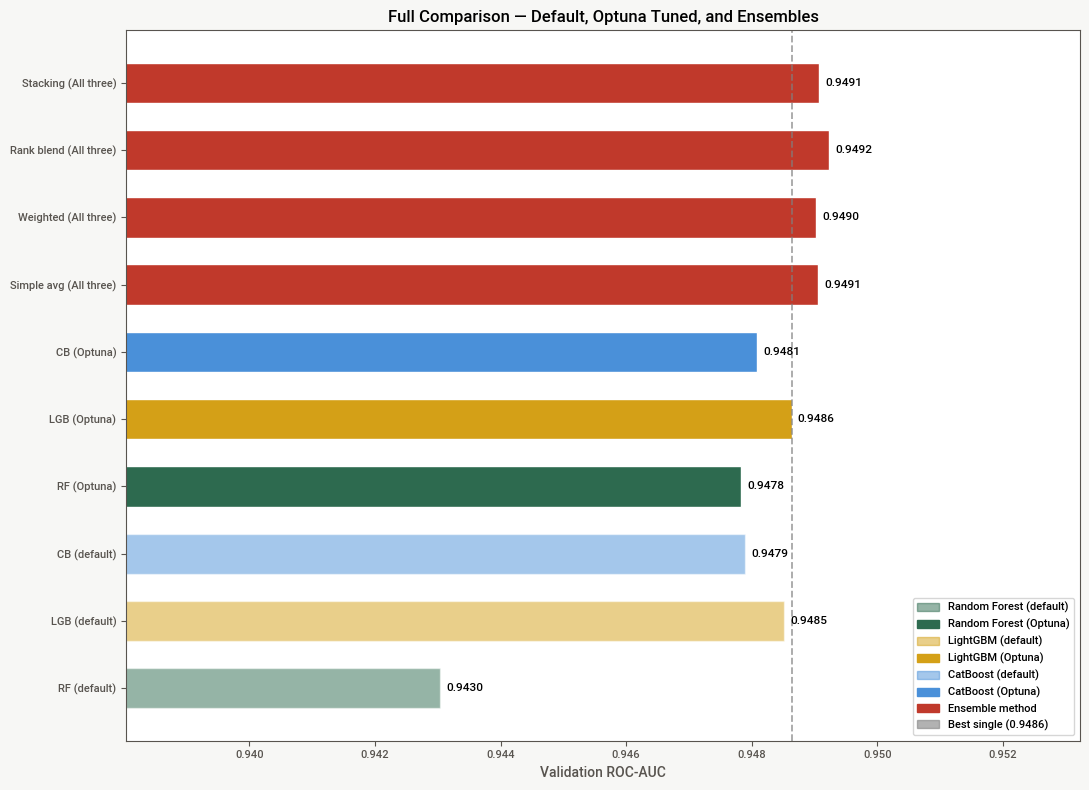

In [408]:
# full comparison: defaults, optuna-tuned, and best ensemble combinations
# ordered to show the progression from baseline through tuning through ensembling

#want to show bar chart to visually compare results

all_results = [
    # default models — no tuning
    ('RF (default)',              default_scores['Random Forest'], C0,  0.5),
    ('LGB (default)',             default_scores['LightGBM'],      C1,  0.5),
    ('CB (default)',              default_scores['CatBoost'],       C2,  0.5),
    # optuna-tuned models
    ('RF (Optuna)',                rf_auc,                          C0,  1.0),
    ('LGB (Optuna)',               lgb_auc,                         C1,  1.0),
    ('CB (Optuna)',                cb_auc,                          C2,  1.0),
    # best ensemble combinations
    (f'Simple avg ({best_combo})',           simple_avg_auc,        C3,  1.0),
    (f'Weighted ({best_weighted_combo})',    weighted_blend_auc,    C3,  1.0),
    (f'Rank blend ({best_rank_combo})',      rank_blend_auc,        C3,  1.0),
    (f'Stacking ({best_stack_combo})',       stack_auc,             C3,  1.0),
]

names_s  = [x[0] for x in all_results]
aucs_s   = [x[1] for x in all_results]
colors_s = [x[2] for x in all_results]
alphas_s = [x[3] for x in all_results]

fig, ax = plt.subplots(figsize=(11, 8), facecolor=BG)

bars = ax.barh(names_s, aucs_s, color=colors_s,
               edgecolor='white', height=0.6,
               alpha=1.0)

# apply alpha manually to distinguish default from tuned
for bar, alpha in zip(bars, alphas_s):
    bar.set_alpha(alpha)

for bar, val in zip(bars, aucs_s):
    ax.text(val + 0.0001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8.5)

# reference line at best single optuna model
ax.axvline(best_single, color='gray', ls='--', lw=1.3, alpha=0.7,
           label=f'Best single Optuna ({best_single:.4f})')

ax.set_xlabel('Validation ROC-AUC')
ax.set_title('Full Comparison — Default, Optuna Tuned, and Ensembles',
             fontweight='bold')
ax.set_xlim(min(aucs_s) - 0.005, max(aucs_s) + 0.004)

legend_handles = [
    mpatches.Patch(color=C0, alpha=0.5, label='Random Forest (default)'),
    mpatches.Patch(color=C0, alpha=1.0, label='Random Forest (Optuna)'),
    mpatches.Patch(color=C1, alpha=0.5, label='LightGBM (default)'),
    mpatches.Patch(color=C1, alpha=1.0, label='LightGBM (Optuna)'),
    mpatches.Patch(color=C2, alpha=0.5, label='CatBoost (default)'),
    mpatches.Patch(color=C2, alpha=1.0, label='CatBoost (Optuna)'),
    mpatches.Patch(color=C3, alpha=1.0, label='Ensemble method'),
    mpatches.Patch(color='gray', alpha=0.6, label=f'Best single ({best_single:.4f})'),
]
ax.legend(handles=legend_handles, fontsize=8, loc='lower right')

fig.tight_layout()
plt.show()

### 6. Results Summary

Goals: Summarize the models you evaluated and identify your final model. Include model name, key preprocessing or features, validation method, evaluation metric, validation score, and a brief reason for your final choice. Present this in a clear, structured format.

**Shared setup across all models:**

| Component | Decision | Source |
|---|---|---|
| Dataset | 32,950 train / 8,238 test | — |
| Features | 42 (34 original + 8 engineered) | Section 3 |
| Dropped features | 20 low-signal columns (3 engineered + 17 OHE) | Section 3 |
| Validation method | 5-fold stratified CV (tuning) + 20% held-out val set (evaluation) | Section 4 |
| Primary metric | ROC-AUC | Section 1 (EDA) |
| Secondary metric | F1 at optimal threshold | Section 4 |
| Class imbalance | Handled in all models via class weighting (7.87:1 ratio) | Section 4 |
| Key engineered features | `contact_efficiency`, `age_x_long_call`, `macro_environment`, `contact_time_x_peak`, `campaign_pressure`, `age_squared`, `age_group_encoded`, `prior_contact_rate` | Section 3 |

In [409]:
from sklearn.metrics import roc_auc_score, precision_recall_curve

def get_f1_at_optimal_threshold(y_true, probs):
    precision, recall, thresholds = precision_recall_curve(y_true, probs)
    f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
    best_idx  = np.argmax(f1_scores[:-1])
    return round(thresholds[best_idx], 3), round(f1_scores[best_idx], 4)


rows = []

# --- default models: CV AUC only, no val evaluation at this stage ---
for name in ['Random Forest', 'LightGBM', 'CatBoost']:
    rows.append({
        'Group':    'Modeling - Default',
        'Model':    name,
        'CV AUC':   round(default_scores[name], 4),
        'Val AUC':  '—',
        'F1':       '—',
        'Threshold':'—',
        'Final?':   '',
    })

# --- Optuna-tuned models: CV AUC, val AUC, F1, and threshold ---
for name, search, val_probs in [
    ('Random Forest', rf_search,  rf_val_probs),
    ('LightGBM',      lgb_search, lgb_val_probs),
    ('CatBoost',      cb_search,  cb_val_probs),
]:
    t, f = get_f1_at_optimal_threshold(y_val, val_probs)
    rows.append({
        'Group':    'Modeling - Optuna Tuned',
        'Model':    name,
        'CV AUC':   round(search.best_score_, 4),
        'Val AUC':  round(roc_auc_score(y_val, val_probs), 4),
        'F1':       f,
        'Threshold': t,
        'Final?':   '',
    })

# --- ensemble methods: using the best combination found for each method ---
ensemble_entries = [
    (f'Simple Avg ({best_combo})',          simple_avg_probs,  simple_avg_auc),
    (f'Weighted ({best_weighted_combo})',   weighted_blend,    weighted_blend_auc),
    (f'Rank Blend ({best_rank_combo})',     rank_blend,        rank_blend_auc),
    (f'Stacking ({best_stack_combo})',      stack_val_probs,   stack_auc),
]

for name, probs, auc in ensemble_entries:
    t, f = get_f1_at_optimal_threshold(y_val, probs)
    rows.append({
        'Group':    'Ensembling',
        'Model':    name,
        'CV AUC':   '—',
        'Val AUC':  round(auc, 4),
        'F1':       f,
        'Threshold': t,
        'Final?':   '',
    })

df = pd.DataFrame(rows)

# pick final model: highest val AUC across Optuna-tuned and ensemble rows
# excluding defaults since they have no val AUC
candidates = df[df['Val AUC'] != '—'].copy()
candidates['Val AUC'] = candidates['Val AUC'].astype(float)
candidates['F1']      = candidates['F1'].astype(float)

# sort by val AUC first, then F1 as tiebreaker
candidates = candidates.sort_values(['Val AUC', 'F1'], ascending=False)
final_model_name = candidates.iloc[0]['Model']

df.loc[df['Model'] == final_model_name, 'Final?'] = '*** FINAL'

# print each group as its own labeled section
for group in ['Modeling - Default', 'Modeling - Optuna Tuned', 'Ensembling']:
    subset = df[df['Group'] == group].reset_index(drop=True)
    print(f"\n{'─' * 75}")
    print(f"  {group}")
    print(f"{'─' * 75}")
    print(f"  {'Model':<32} {'CV AUC':>8}  {'Val AUC':>8}  {'F1':>7}  {'Threshold':>10}  {'':>9}")
    print(f"  {'─'*32} {'─'*8}  {'─'*8}  {'─'*7}  {'─'*10}  {'─'*9}")
    for _, row in subset.iterrows():
        print(f"  {row['Model']:<32} "
              f"{str(row['CV AUC']):>8}  "
              f"{str(row['Val AUC']):>8}  "
              f"{str(row['F1']):>7}  "
              f"{str(row['Threshold']):>10}  "
              f"{str(row['Final?']):>9}")

print(f"\n{'─' * 75}")
print(f"  *** = final model | Val AUC = "
      f"{candidates.iloc[0]['Val AUC']:.4f} | F1 = {candidates.iloc[0]['F1']:.4f}")
print(f"{'─' * 75}")


───────────────────────────────────────────────────────────────────────────
  Modeling - Default
───────────────────────────────────────────────────────────────────────────
  Model                              CV AUC   Val AUC       F1   Threshold           
  ──────────────────────────────── ────────  ────────  ───────  ──────────  ─────────
  Random Forest                       0.943         —        —           —           
  LightGBM                           0.9485         —        —           —           
  CatBoost                           0.9479         —        —           —           

───────────────────────────────────────────────────────────────────────────
  Modeling - Optuna Tuned
───────────────────────────────────────────────────────────────────────────
  Model                              CV AUC   Val AUC       F1   Threshold           
  ──────────────────────────────── ────────  ────────  ───────  ──────────  ─────────
  Random Forest                      0.9486  

Rank blending was selected as the final model because it achieved the highest validation performance, although all ensemble methods were essentially tied. The improvement over simple averaging and stacking was very small, so as long as some kind of ensembling is chosen the model will do well at predicting.

This choice aligns with the overall workflow. Random Forest, LightGBM, and CatBoost each performed similarly well but capture patterns differently due to their underlying algorithms. Since no single model clearly dominated, combining them helped leverage their complementary strengths. Rank blending in particular preserves the relative ordering of predictions while reducing sensitivity to differences in probability calibration across models.

In a real business setting, I would also recommend comparing the computational cost and runtime of each ensemble approach. Since the models are performing very similarly, it may be more practical to choose the most cost efficient method rather than the one with the marginally highest validation score. For now, given that I do not have pricing information and the model runtime was somewhat similar, I am choosing rank blending based on the above reasoning ^. 

**Final Model:** Rank Blend Ensemble (Random Forest, LightGBM, and catboost)

**Key Preprocessing and Features**
All models were trained on 42 features after dropping 20 low-signal columns identified in section 3. Preprocessing included log-transforming skewed contact features, replacing the sentinel value in days since prior contact with a binary flag, and dropping two collinear economic columns. Eight engineered features were added based on EDA findings and domain hypotheses, with the strongest being contact efficiency, age times log call duration, macro environment score, and contact time in peak months.

**Validation Method**
5-fold stratified cross-validation was used for hyperparameter tuning to preserve the 11.3% positive class rate across all folds. Final model evaluation used a held-out 20% validation set that was never seen during tuning or feature selection.

**Evaluation Metrics**
Primary: ROC-AUC. Secondary: F1 at the optimal decision threshold.

5-fold stratified CV is appropriate because the 11.3% positive class rate is preserved in every fold, so no fold accidentally gets an unrepresentative sample of acceptors. The 20% held-out validation set kept completely separate from tuning gives an unbiased final evaluation. ROC-AUC is appropriate because accuracy would be misleading at 11.3% imbalance, and AUC measures ranking quality across all thresholds which is exactly right for a campaign where you rank customers by likelihood. F1 at optimal threshold as secondary is appropriate because it captures the precision-recall tradeoff at an actionable cutoff rather than assuming 0.5.

**Validation Scores**
Val AUC: 0.9492

**Why This Model**
Rank blending RF, LightGBM, and catboost is the final model. All ensemble methods produced similar validation AUCs, so F1 and simplicity were the tiebreakers. Rank blend requires no fitting or optimization on the validation set, so there is smaller data leakage risk. It is also a simpler method that produces the top result and is straightforward to reproduce and explain. I go into more depth up above ^

### 7. Final Model and Predictions

Goals: Train your final model and generate predictions for the test set. Do not use the test set for tuning.

**I set up the code to work for any of the possible models just because initially the results I found were changing constantly and I wanted to be able to see this part even when doing drafts and didn't want to have to change it if I re-ran things.**

The final model is a rank blend of Random Forest, LightGBM, and catboost, selected in section 6.

Two things change for final predictions compared to the validation evaluation:
- Both models are retrained on the **full training set** (train + val combined). Holding out validation data during section 4 and 5 was necessary for honest evaluation, but now that all decisions are locked in, including that data in training gives the model more signal.
- The **optimal threshold** found on the validation set in section 5 is applied to convert probabilities to 0/1 predictions.

The test set is not used in any way during training or threshold selection.

In [410]:
from scipy.stats import rankdata
from sklearn.metrics import precision_recall_curve

# Step 1: Retrain base models on full training data 

X_full_train = pd.concat([X_train, X_val], axis=0)
y_full_train = pd.concat([y_train, y_val], axis=0)

print(f"Full training set: {X_full_train.shape[0]:,} rows")
print(f"Positive rate:     {y_full_train.mean():.3f}")

# retrain all three models so any combination can be used
rf_final  = rf_search.best_estimator_
lgb_final = lgb_search.best_estimator_
cb_final  = cb_search.best_estimator_

rf_final.fit(X_full_train,  y_full_train)
lgb_final.fit(X_full_train, y_full_train)
cb_final.fit(X_full_train,  y_full_train)

print("All three models retrained on full training set.")
print(f"Final model selected in section 6: {final_model_name}")

Full training set: 32,950 rows
Positive rate:     0.113
All three models retrained on full training set.
Final model selected in section 6: Rank Blend (All three)


In [411]:
# Step 2: Generate test predictions using the correct method 

# generate test probabilities from all three models
rf_test_probs  = rf_final.predict_proba(X_test_final)[:, 1]
lgb_test_probs = lgb_final.predict_proba(X_test_final)[:, 1]
cb_test_probs  = cb_final.predict_proba(X_test_final)[:, 1]

# map model name to its test probabilities
test_probs_map = {
    'rf':  rf_test_probs,
    'lgb': lgb_test_probs,
    'cb':  cb_test_probs,
}

# map model name to its validation probabilities (for threshold computation)
val_probs_lookup = {
    'Random Forest': rf_val_probs,
    'LightGBM':      lgb_val_probs,
    'CatBoost':      cb_val_probs,
    f'Simple Avg ({best_combo})':          simple_avg_probs,
    f'Weighted ({best_weighted_combo})':   weighted_blend,
    f'Rank Blend ({best_rank_combo})':     rank_blend,
    f'Stacking ({best_stack_combo})':      stack_val_probs,
}

# determine which test probs to use based on the combo name
def get_combo_test_probs(combo_name):
    # parse which models are in the combo from the name
    use_rf  = 'RF'    in combo_name
    use_lgb = 'LGB'   in combo_name
    use_cb  = 'CB'    in combo_name or 'three' in combo_name
    if 'three' in combo_name:
        use_rf = use_lgb = use_cb = True
    probs_list = []
    if use_rf:  probs_list.append(rf_test_probs)
    if use_lgb: probs_list.append(lgb_test_probs)
    if use_cb:  probs_list.append(cb_test_probs)
    return probs_list

# apply the right blending method based on what was selected in section 6
if final_model_name.startswith('Simple Avg'):
    # unweighted average of test probabilities
    probs_list = get_combo_test_probs(best_combo)
    test_blend = np.mean(probs_list, axis=0)
    print(f"Method: simple average | Combo: {best_combo}")

elif final_model_name.startswith('Weighted'):
    # apply OOF-optimized weights to test probabilities
    # best_weights was found using OOF on training data — no leakage
    probs_list = get_combo_test_probs(best_weighted_combo)
    test_blend = sum(best_weights[i] * probs_list[i] for i in range(len(probs_list)))
    print(f"Method: weighted blend | Combo: {best_weighted_combo}")
    print(f"Weights: {[round(w, 3) for w in best_weights]}")

elif final_model_name.startswith('Rank Blend'):
    # convert each model's probabilities to rank percentiles, then average
    probs_list = get_combo_test_probs(best_rank_combo)
    ranks_list = [rankdata(p) / len(p) for p in probs_list]
    test_blend = np.mean(ranks_list, axis=0)
    print(f"Method: rank blend | Combo: {best_rank_combo}")

elif final_model_name.startswith('Stacking'):
    # apply the trained meta-learner to test probabilities
    # meta-learner was trained on OOF predictions in section 5
    best_meta = stack_results[best_stack_combo][2]
    probs_list = get_combo_test_probs(best_stack_combo)
    meta_X_test = np.column_stack(probs_list)
    test_blend  = best_meta.predict_proba(meta_X_test)[:, 1]
    print(f"Method: stacking | Combo: {best_stack_combo}")

else:
    # individual model — no blending needed
    single_map = {'Random Forest': rf_test_probs,
                  'LightGBM':      lgb_test_probs,
                  'CatBoost':      cb_test_probs}
    test_blend = single_map[final_model_name]
    print(f"Method: individual model | {final_model_name}")

print(f"\nTest blend — min: {test_blend.min():.4f}, "
      f"median: {np.median(test_blend):.4f}, max: {test_blend.max():.4f}")

Method: rank blend | Combo: All three

Test blend — min: 0.0043, median: 0.4905, max: 0.9998


In [412]:
# Step 3: Apply threshold and save predictions 

# compute the F1-optimal threshold from the final model's validation predictions
# this is the same threshold logic used throughout section 5
# the test set has no influence on this value
final_val_probs = val_probs_lookup[final_model_name]

precision, recall, thresholds = precision_recall_curve(y_val, final_val_probs)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
THRESHOLD = float(thresholds[np.argmax(f1_scores[:-1])])

print(f"Final model:               {final_model_name}")
print(f"Optimal threshold (val):   {THRESHOLD:.4f}")

# apply threshold to convert probabilities to 0/1 predictions
test_predictions = (test_blend >= THRESHOLD).astype(int)

# load test ids and build submission file
test_ids = pd.read_csv('midterm_test.csv')['id']

submission = pd.DataFrame({
    'id':         test_ids.values,
    'prediction': test_predictions
})

submission.to_csv('kopecek_karisa_predictions.csv', index=False)

print(f"Predictions saved: {len(submission):,} rows")
print(f"\nPrediction distribution:")
print(f"  Not accepted (0): {(submission['prediction']==0).sum():,}  "
      f"({(submission['prediction']==0).mean()*100:.1f}%)")
print(f"  Accepted (1):     {(submission['prediction']==1).sum():,}  "
      f"({(submission['prediction']==1).mean()*100:.1f}%)")
print(f"\nPreview:")
print(submission.head(10).to_string(index=False))

Final model:               Rank Blend (All three)
Optimal threshold (val):   0.8292
Predictions saved: 8,238 rows

Prediction distribution:
  Not accepted (0): 6,816  (82.7%)
  Accepted (1):     1,422  (17.3%)

Preview:
   id  prediction
32884           0
 3169           1
32206           1
 9403           0
14020           0
17201           0
  879           0
23757           1
10821           0
14355           0
